# T27 — REVEAL mantle tomography: vertical cross-sections through Courtillot's hotspots
> **Data availability.** This notebook depends on external dataset(s) that will be distributed via the suite's Zenodo archive, which has not been uploaded yet as of this writing. This notebook will not run until that upload is complete.



**Cluster E: Mantle dynamics + dynamic topography.**
**Are the world's hotspots fed by deep mantle plumes — or do they bottom out partway down?**

Sibling notebook to T31 (REVEAL depth slices + reconstructed plate boundaries). Where T31 cuts REVEAL *horizontally* and overlays past trenches to test the slab-graveyard hypothesis, T33 cuts it *vertically* through hotspot locations to test the deep-plume hypothesis. Courtillot, Davaille, Besse & Stock (2003) ranked 49 hotspots against five criteria of deep-plume origin and assigned each a 0–4 score (their Table 1). Hotspots with score 4 (Hawaii, Iceland, Réunion, Easter, Samoa, Afar) are the strongest candidates for full lower-mantle plumes; the 16 hotspots with score 2 or 3 are the *ambiguous cases* whose deep mantle structure this notebook helps you reassess. This notebook lets you cut a REVEAL slice through any of them and look at the geometry as a wedge through the Earth.

### Why the depth profile matters — mid-mantle plume and slab arrest

While some plumes appear to rise continuously from the core-mantle boundary to the surface (Hawaii, Iceland, Réunion), seismic tomography and geodynamic modelling show that many plumes — and many sinking slabs — flatten or pause at characteristic depths in the mid-mantle. The best-known of these is the **660 km transition**, the base of the mantle transition zone, where the olivine polymorph ringwoodite breaks down to bridgmanite + ferropericlase under increasing pressure. This is a true mineral phase change and is associated with a viscosity increase between the upper and lower mantle.

A second, less well understood depth range lies between roughly **800 and 1200 km**, sometimes called the **middle-mantle transition zone (MMTZ)**. Tomographic studies (e.g. Rudolph, Lekić & Lithgow-Bertelloni 2015) and geodynamic inversions consistently show plumes and slabs slowing, broadening, or deflecting through this depth interval, even though no candidate mineral phase change had traditionally been identified there. Rudolph et al. attributed the MMTZ to a viscosity jump rather than a phase change. More recent high-pressure mineral physics experiments (Dong et al. 2025) suggest that a previously-unrecognised post-spinel-related phase transition may also contribute to the MMTZ's mechanical character. Whether one or both processes are responsible, the practical consequence for the wedges you'll render below is that you should expect candidate plumes to potentially terminate at either \~660 km, somewhere in the \~800–1200 km MMTZ, or only at the core-mantle boundary at 2890 km — those three possibilities are what the 0–4 Courtillot score is trying to discriminate, with much better spatial resolution than was available in 2003.

## What this notebook produces

1. **Cell 1** — Loads Courtillot et al. (2003) Table 1 as a clean CSV (`data/courtillot_2003_hotspots/courtillot_2003_table1.csv`), with a detailed walk-through of what every column means.
2. **Cell 2** — Locates `REVEAL.nc` (the full \~412 MB tomography grid) on disk.
3. **Cells 3–4** — Per-depth lateral-mean removal (the standard tomography anomaly), great-circle path sampling helpers, and an Earth-shaped **polar wedge cross-section** matching the style of the example notebook in `external/REVEAL_plume_tutorial/`.
4. **Cell 5** — One worked example: wedge cross-section through the chosen hotspot.
5. **Cell 6** — Locator map: pyGMT globe centred on the hotspot, showing all candidate hotspots and the great-circle path of the cross-section.
6. **Cell 7** — The 8-hotspot deliverable for the GEOS3101 prac: a 2×4 panel of wedges.

## What you'll see in the wedges

Slow seismic anomalies (red in the diverging colourmap) mark hot, low-rigidity material that is likely upwelling. A **deep plume** shows continuous slow anomaly from the surface (outer arc) right down to the core–mantle boundary (inner arc at 2890 km). A **transition-zone-stalled** or **mid-mantle-stalled** plume shows the slow anomaly bottoming out at one of the experimentally documented sticking-points — the 660 km post-spinel transition or the \~1000 km bridgmanite/post-perovskite-related transition discussed in Dong et al. (2025). Three dashed arcs at 410, 660, and 1000 km mark these interfaces on the wedge.

**Audience**: postgrad / GEOS3101 (undergrad-friendly when supervised).
**Difficulty**: ★★.
**Runtime**: \~30 s per single cross-section once REVEAL.nc is loaded; \~3 min for the 8-panel comparison.


## Data

Two inputs:

1. **REVEAL global full-waveform inversion** (Thrastarson, van Herwaarden, Noe, Schiller & Fichtner 2024, *BSSA* 114(3), 1392–1406; DOI 10.1785/0120230273) — the full \~412 MB NetCDF file (`REVEAL.nc`) on a 0.5° × 0.5° × 99-depth grid (0–2880 km). This notebook expects the file at one of the paths in `REVEAL_PATH_CANDIDATES` (cell 2 below). Suggested location: `external/REVEAL_plume_tutorial/Models/REVEAL.nc` (matches the GEOS3101 prac directory layout). The file is *too large to bundle on GitHub* — keep it local.
2. **Courtillot, Davaille, Besse & Stock (2003) Table 1** (*EPSL* 205(3–4), 295–308) — extracted from the published paper image as `data/courtillot_2003_hotspots/courtillot_2003_table1.csv`. Bundled with the suite (\~3 kB). Columns are explained in detail after the CSV is loaded in §1 below.


## Environment + imports

In [1]:
# Defensive cwd fix — when Jupyter launches this notebook from Notebooks/,
# the data/... relative paths below would not resolve. Step up to the
# project root once so every 'data/...' literal in the rest of the
# notebook finds its file. Idempotent.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import xarray as xr
import pygmt

# Colormap for tomography anomalies — GMT ships Fabio Crameri's perceptually
# uniform 'roma' palette out of the box, the seismological standard for
# cool-vs-hot anomalies (and what the reference REVEAL example notebook uses).
# We keep the CPT name as a string so pygmt.makecpt / fig.grdimage consume it
# natively; no matplotlib dependency.
TOMOGRAPHY_CMAP = "roma"
CMAP_NAME       = "roma (Crameri; shipped with GMT)"

pygmt.config(FONT_TITLE="18p", FONT_LABEL="14p", FONT_ANNOT_PRIMARY="12p")

print("Environment")
print(f"  python    {sys.version.split()[0]}")
for _m in (np, pd, xr, pygmt):
    print(f"  {_m.__name__:9s} {getattr(_m, '__version__', 'n/a')}")
print(f"  cmap      {CMAP_NAME}")


Environment
  python    3.12.5
  numpy     2.3.2
  pandas    2.2.3
  xarray    2026.4.0
  pygmt     v0.18.0
  cmap      roma (Crameri; shipped with GMT)


In [2]:
# === USER CONFIGURATION =====================================================
# All knobs the prac asks you to vary live in this single block. Each
# variable is explained in the markdown cell that follows. Edit the values
# here, then re-run cells 5 + 6 to see the new cross-section.

HOTSPOT_NAME           = "Iceland"
AZIMUTH_DEG            =  90.0     # E-W across the Mid-Atlantic Ridge through Iceland
HALF_WIDTH_DEG         =  30.0

ANOMALY_LIMITS_PCT     = 4.0
PHASE_DEPTHS_KM        = [410, 660, 1000]

N_PATH_POINTS          = 201

# Reconstruction-map snapshot ages for §9. Default 30 + 80 Ma so the
# Cenozoic and Mesozoic portions of most hotspot tracks are sampled by
# the two globes. Set to any pair of ages within TRACK_MAX_AGE_MA.
RECON_DEMO_TIME_A_MA   =  30.0     # younger snapshot (Cenozoic by default)
RECON_DEMO_TIME_B_MA   =  80.0     # older snapshot (Mesozoic by default)

MIN_DEPTH_KM           =   50.0
MAX_DEPTH_KM           = 2900.0
EARTH_RADIUS_KM        = 6371.0

# REVEAL.nc ships in the suite's Zenodo data archive (not on GitHub —
# ~412 MB). Download it and extract as zenodo_data/ at the repo root
# (sibling of Notebooks/ and data/); see Notebooks/README.md > External
# data dependencies. (data/reveal_tomography/ is a *different*, smaller,
# already-bundled set of pre-sliced depth grids used by T26 — not this file.)
REVEAL_DIR = Path(os.environ.get("ZENODO_REVEAL_DIR", "zenodo_data/REVEAL_mantle_tomography"))
REVEAL_PATH_CANDIDATES = [REVEAL_DIR / "REVEAL.nc"]
COURTILLOT_CSV         = Path("data/courtillot_2003_hotspots/courtillot_2003_table1.csv")
# ============================================================================

### What each USER CONFIGURATION variable means

| Variable | What it does |
|---|---|
| **`HOTSPOT_NAME`** | Name of the hotspot to slice through. Must match the `hotspot` column in the Courtillot CSV (case-insensitive). Try any of the 49 names in §1's printout — `"Hawaii"`, `"Iceland"`, `"Yellowstone"`, `"Tristan"`, `"Caroline"`, etc. |
| **`AZIMUTH_DEG`** | Orientation of the great-circle path through the hotspot, measured **clockwise from North** in degrees. `0` = N–S, `90` = W–E, `180` = N–S (south-going), `270` = E–W. For Iceland, `90°` cuts east–west across the Mid-Atlantic Ridge through the plume; for Hawaii, `120°` traces roughly along the Hawaii-Emperor chain; for Yellowstone, `65°` traces the Snake River–Yellowstone track. **You're expected to vary this** to align your slice with the suspected plume tilt or hotspot-track direction. |
| **`HALF_WIDTH_DEG`** | Half the angular length of the cross-section, in degrees of great-circle arc. The path spans **2 × HALF_WIDTH_DEG** total (the hotspot is located at the midpoint). `30°` ≈ 3300 km — wide enough to make the wedge clearly annular; for a tight conduit zoom try `15°`; for a global slice try `90°`. |
| **`ANOMALY_LIMITS_PCT`** | Saturation limit (in percent) for the colour scale. The colourmap spans **±ANOMALY_LIMITS_PCT** with white at zero. `4 %` is the standard tomography display range; reduce to `2 %` to bring out faint deep-mantle features, or increase to `6 %` if a strong shallow feature is washing everything else out. |
| **`PHASE_DEPTHS_KM`** | Depths (km) at which to draw dashed reference arcs on the wedge. The defaults are the three mantle phase transitions you're asked to look at: **410 km** (olivine → wadsleyite), **660 km** (ringwoodite → bridgmanite — the top of the lower mantle), and **\~1000 km** (the mid-mantle viscosity / phase-transition zone discussed by Dong et al. 2025). |
| **`N_PATH_POINTS`** | Number of points sampled along the great-circle path. `201` is fine for the GEOS3101 prac. Increase to `401` for higher horizontal resolution at the cost of slower rendering. |
| **`RECON_DEMO_TIME_A_MA` / `RECON_DEMO_TIME_B_MA`** | The two ages (Ma) for the paired reconstructed-globe panels in §9. Defaults are `30` + `80` so one panel shows a Cenozoic snapshot and the other a Mesozoic snapshot of the hotspot's plate environment. Pick any two ages within `TRACK_MAX_AGE_MA` to focus on a particular epoch of your chosen hotspot's history (e.g. `60` + `120` for Iceland to catch the NAIP eruption window and a deep-Mesozoic baseline). |
| **`MIN_DEPTH_KM` / `MAX_DEPTH_KM`** | Vertical extent of the wedge. REVEAL extends 0–2880 km; `50–2900` is the standard display range (the top 50 km is dominated by ocean / lithosphere effects that aren't the mantle structure we care about). |
| **`EARTH_RADIUS_KM`** | Used to map depth → radius for the wedge plot (surface at r = 6371 km, CMB at r = 6371 − 2890 = 3481 km). Should not be changed. |
| **`REVEAL_PATH_CANDIDATES`** | List of paths to look for `REVEAL.nc`. The notebook uses the first one that exists. If yours is somewhere else, prepend its path to the list. |
| **`COURTILLOT_CSV`** | Path to the bundled Courtillot 2003 Table 1 CSV. Don't change unless you've moved the file. |

**Workflow**: edit the top three (`HOTSPOT_NAME`, `AZIMUTH_DEG`, `HALF_WIDTH_DEG`), re-run cells 5 + 6 to see the new cross-section, repeat until you've picked an orientation that shows the plume conduit's geometry clearly.


## 1. Load the Courtillot 2003 hotspot table

In [3]:
if not COURTILLOT_CSV.exists():
    raise FileNotFoundError(
        f"Courtillot 2003 hotspot table not found at {COURTILLOT_CSV}. "
        "This file ships with the tutorial suite — make sure you're running "
        "from the project root.")

hot = pd.read_csv(COURTILLOT_CSV)
print(f"  loaded {len(hot)} hotspots from Courtillot 2003 Table 1")
print(f"  Courtillot score (0-4) distribution: "
      f"{dict(hot['count'].value_counts().sort_index())}")

# Summary subsets the prac uses (just for the printed counts below — the
# HTML table that follows shows ALL 49, three-way colour-coded).
primary    = hot[hot["count"] == 4]
ambiguous  = hot[hot["count"].isin([2, 3])]
background = hot[hot["count"].isin([0, 1])]
print(f"  primary (count = 4):    n = {len(primary):2d}")
print(f"  ambiguous (count 2/3):  n = {len(ambiguous):2d}  <-- prac main subset")
print(f"  background (count 0/1): n = {len(background):2d}")

# ---------------------------------------------------------------------------
# Build a styled HTML table showing ALL 49 hotspots so the prac can pick
# any of them as HOTSPOT_NAME. Sort by Courtillot count descending, then
# by name. Row-style tiers (colour + Courtillot's published typographic
# convention from Table 1: bold for count >= 2, bold italic for count >= 3):
#   count = 4       -> bold italic dark red on white   (primary plumes; >= 3)
#   count = 3       -> bold italic dark orange on light yellow (>= 3)
#   count = 2       -> bold        dark orange on light yellow (>= 2)
#   count in {0,1}  -> regular gray text                       (no evidence)
# ---------------------------------------------------------------------------
from IPython.display import display, HTML

_sorted = hot.sort_values(["count", "hotspot"], ascending=[False, True])

def _row_style(cnt: int) -> str:
    # Courtillot Table 1 typographic convention: bold for count >= 2,
    # bold italic for count >= 3. Layer on top of the colour tiers.
    typog = ""
    if cnt >= 2:
        typog += " font-weight:bold;"
    if cnt >= 3:
        typog += " font-style:italic;"
    if cnt == 4:
        return f"background:#ffffff; color:#8b0000;{typog}"
    if cnt in (2, 3):
        return f"background:#fff8dc; color:#cc6600;{typog}"
    return "background:#ffffff; color:#808080;"

def _truncate(s, n=44):
    s = "" if pd.isna(s) else str(s)
    return s if len(s) <= n else s[: n - 1] + "…"

_header_cells = "".join(
    f"<th style='padding:4px 8px; border-bottom:1px solid #888; "
    f"text-align:{align}; background:#f0f0f0;'>{label}</th>"
    for label, align in [
        ("hotspot", "left"),
        ("lat", "right"),
        ("lon (°E)", "right"),
        ("Courtillot count", "center"),
        ("³He/⁴He", "center"),
        ("tomo anomaly", "center"),
        ("raw context", "left"),
    ]
)

_rows_html = []
for _, r in _sorted.iterrows():
    cnt = int(r["count"])
    flag = " +?" if bool(r.get("uncertain", False)) else ""
    he   = "" if pd.isna(r.get("he_ratio"))     else str(r["he_ratio"])
    tomo = "" if pd.isna(r.get("tomo_anomaly")) else str(r["tomo_anomaly"])
    raw  = _truncate(r.get("raw_rest", ""))
    _rows_html.append(
        f"<tr style='{_row_style(cnt)}'>"
        f"<td style='padding:3px 8px;'>{r['hotspot']}</td>"
        f"<td style='padding:3px 8px; text-align:right;'>{r['lat']:+.1f}</td>"
        f"<td style='padding:3px 8px; text-align:right;'>{r['lon_180']:+.1f}</td>"
        f"<td style='padding:3px 8px; text-align:center;'>{cnt}{flag}</td>"
        f"<td style='padding:3px 8px; text-align:center;'>{he}</td>"
        f"<td style='padding:3px 8px; text-align:center;'>{tomo}</td>"
        f"<td style='padding:3px 8px; font-family:monospace; font-size:90%;'>{raw}</td>"
        f"</tr>"
    )

_legend = (
    "<p style='margin:0 0 6px 0; font-size:95%;'>"
    "<i>Per Courtillot et al. (2003) Table 1 typographic convention: "
    "hotspots with count ≥ 2 are <b>bold</b>; hotspots with count ≥ 3 are "
    "<b><i>bold italic</i></b>. On top of that we colour-code by Courtillot "
    "tier: count = 4 (primary candidate deep plumes, n = 6) in "
    "<span style='color:#8b0000; font-weight:bold; font-style:italic;'>dark red</span>, "
    "count = 2 or 3 (the prac's main 16 target hotspots) in "
    "<span style='color:#cc6600; background:#fff8dc; font-weight:bold; "
    "padding:0 4px;'>dark orange on light yellow</span>, "
    "count = 0 or 1 (no Courtillot evidence, n = 27) in "
    "<span style='color:#808080;'>grey</span> for reference.</i></p>"
)

_table_html = (
    f"{_legend}"
    f"<table style='border-collapse:collapse; font-family:sans-serif; "
    f"font-size:92%; margin-top:4px;'>"
    f"<thead><tr>{_header_cells}</tr></thead>"
    f"<tbody>{''.join(_rows_html)}</tbody>"
    f"</table>"
)
display(HTML(_table_html))


  loaded 49 hotspots from Courtillot 2003 Table 1
  Courtillot score (0-4) distribution: {0: np.int64(15), 1: np.int64(12), 2: np.int64(13), 3: np.int64(3), 4: np.int64(6)}
  primary (count = 4):    n =  6
  ambiguous (count 2/3):  n = 16  <-- prac main subset
  background (count 0/1): n = 27


hotspot,lat,lon (°E),Courtillot count,³He/⁴He,tomo anomaly,raw context
Afar,+10.0,+43.0,4,high,slow,no Ethiopia 30 1 good high slow 4
Easter,-27.0,-110.0,4 +?,high,slow,yes mid-Pac mnt? 1002 3 fair high slow 4+?
Hawaii,+20.0,-156.0,4 +?,high,slow,yes subducted? >80? 8.7 good high slow 4+?
Iceland,+65.0,-20.0,4 +?,high,slow,yes? Greenland 61 1.4 good high slow 4+?
Reunion,-21.0,+56.0,4,high,,yes Deccan 65 1.9 poor high 0 4
Samoa,-14.0,-170.0,4,high,slow,yes no? 14? 1.6 poor high slow 4
Caroline,+5.0,+164.0,3,high,,yes no / 2 poor high 0 3
Louisville,-51.0,-141.0,3 +?,,slow,yes Ontong-Java 122 0.9 poor na slow 3+?
Tristan,-37.0,-12.0,3,low,,yes Parana 133 1.7 poor low 0 3
Bowie,+53.0,-135.0,2 +?,,slow,yes no / 0.3 poor na slow 2+?


### What's in the Courtillot Table 1 CSV — column-by-column

Courtillot, Davaille, Besse & Stock (2003) compiled 49 hotspots and ranked each against **five physical criteria** of a deep-plume origin. The bundled CSV captures the columns needed for this tutorial:

| Column | Meaning |
|---|---|
| **`hotspot`** | The hotspot name as printed in Courtillot's original Table 1. Some have parenthetical aliases (e.g. `Macdonald (Cook-Austral)`, `Lord Howe (Tasman East)`). Use these as the `HOTSPOT_NAME` value in the USER CONFIGURATION cell — matching is case-insensitive. |
| **`lat`** | Latitude in degrees, **signed** (positive = north, negative = south). Note that the OCR-extracted Courtillot column was given as e.g. `54S` or `28N`; the CSV stores these as `-54.0` and `+28.0` for direct numerical use. |
| **`lon`** | Longitude in degrees-east, **0 to 360** (Courtillot's original convention). E.g. Hawaii is at `204°E`, Easter Island at `250°E`. |
| **`lon_180`** | Longitude wrapped to **−180 to +180** for easier use with most plotting libraries (e.g. Hawaii at `−156°`, Easter at `−110°`). Use this column when you pass coordinates to pyGMT or matplotlib. |
| **`count`** | The headline Courtillot 0–4 score (the last column of the original Table 1). It's the sum of points assigned across the five physical criteria below. **The higher the count, the more likely the hotspot is fed by a deep mantle plume.** Distribution in the published table: most hotspots score 0 or 1 (no clear plume evidence); 16 score 2 or 3 (ambiguous — the prac's target list); 6 score 4 (strong candidate deep plumes — Hawaii, Iceland, Réunion, Easter, Samoa, Afar). |
| **`uncertain`** | `True` if the original table had a `+?` suffix on the count (e.g. `2+?`, `4+?`), indicating Courtillot was uncertain about the score. `False` for clean scores like `2`, `4`. |
| **`he_ratio`** | A summary of the helium isotope ratio column: `high` if ³He/⁴He is anomalously high (suggesting an undegassed, deep-mantle source), `low` if anomalously low, blank otherwise. **High ³He/⁴He is one of the strongest geochemical arguments for a deep-mantle plume**. |
| **`tomo_anomaly`** | A summary of Courtillot's seismic tomography column: `slow` if a slow shear-wave anomaly was reported beneath the hotspot in the global tomography of the day (2003), `fast` if fast, blank if no clear signal. **In this notebook you're effectively re-doing this assessment with REVEAL — a 2024-vintage full-waveform-inversion model that's far better resolved than what Courtillot had.** |
| **`raw_rest`** | The full remaining text of the OCR-extracted row, preserved for traceability (you generally won't need it). |

### Courtillot's five criteria — what the score actually adds up

The 0–4 score reflects how many of these five physical features Courtillot found for each hotspot (a fifth check, helium isotopes, is folded into the same scale):

1. **A linear hotspot track** — does the hotspot trail a chain of progressively older volcanism in the absolute-plate-motion direction (the textbook "Hawaiian chain" pattern)?
2. **An associated large igneous province (LIP) / flood basalt** — is there a giant outpouring of basalt at the head end of the chain (e.g. Deccan Traps at the start of Réunion's chain, Siberian Traps at the start of Iceland's)?
3. **High buoyancy flux** — is the plume head supporting a measurable bathymetric or topographic swell?
4. **High ³He/⁴He** — does the lava chemistry indicate an undegassed mantle source?
5. **Slow seismic anomaly extending to depth** — does global tomography show a slow column reaching into the lower mantle? **This is the criterion we re-examine in this notebook.**

The 16 score-2/3 ambiguous hotspots are the interesting ones for this prac — they passed *some* of the criteria but not enough to be confident plume candidates. With REVEAL's much higher resolution, you might be able to resolve the ambiguity for individual cases.

## 2. Locate REVEAL.nc

In [4]:
REVEAL_PATH = next((p for p in REVEAL_PATH_CANDIDATES if p.exists()), None)
if REVEAL_PATH is None:
    raise FileNotFoundError(
        f"REVEAL.nc not found under {REVEAL_DIR}/. The full-resolution REVEAL "
        "grid is ~412 MB and ships in the suite's Zenodo data archive, not on "
        "GitHub.\n"
        "  Source: Thrastarson et al. 2024, BSSA 114(3), 1392-1406, "
        "DOI 10.1785/0120230273\n"
        "  Download the suite's Zenodo data archive and extract it as "
        "zenodo_data/ at the repo root, or set the ZENODO_REVEAL_DIR env var."
    )
ds_reveal = xr.open_dataset(REVEAL_PATH)
vsv = ds_reveal["vsv"]
depths_km = ds_reveal["depth"].values.astype(float)
print(f"  REVEAL loaded from {REVEAL_PATH}")
print(f"    grid: depth={vsv.shape[0]} levels, lat={vsv.shape[1]}, lon={vsv.shape[2]}")
print(f"    depth range: {depths_km.min():.0f} – {depths_km.max():.0f} km")
print(f"    vsv range:   {float(vsv.min()):.2f} – {float(vsv.max()):.2f} km/s")

  REVEAL loaded from external/REVEAL_plume_tutorial/Models/REVEAL.nc
    grid: depth=99 levels, lat=361, lon=721
    depth range: 0 – 2880 km
    vsv range:   2.50 – 7.75 km/s


## 3. Helper functions — lateral-mean removal + great-circle sampling + wedge plotter

The display variable in mantle tomography is the *anomaly* relative to the
spherically averaged velocity at each depth — `(v - <v>_depth) / <v>_depth × 100`
in percent. We pre-compute the per-depth lateral mean once and store it,
since the lateral mean is independent of any particular cross-section path.

The **wedge plotter** projects the (along-path angular distance, depth) data
into matplotlib polar axes, with the Earth's surface as the outer arc and
the core-mantle boundary as the inner arc. This is the canonical seismology
rendering — matches the `Slicer.plot_model_cross_section` style of the
example notebook in `external/REVEAL_plume_tutorial/REVEAL_plotting.ipynb`.

In [ ]:
# Per-depth global lateral mean of vsv, computed once for the whole REVEAL
# grid. Result shape: (n_depth,). This is what dvsv anomalies are relative to.
v_mean_depth = vsv.mean(dim=["latitude", "longitude"]).compute()
print(f"  per-depth lateral mean vsv computed: "
      f"{float(v_mean_depth.min()):.2f} – {float(v_mean_depth.max()):.2f} km/s")


def great_circle_path(lon_c: float, lat_c: float, azimuth_deg: float,
                       half_width_deg: float, n: int) -> tuple[np.ndarray, np.ndarray]:
    """Sample N points along a great-circle path through (lon_c, lat_c),
    oriented at `azimuth_deg` (cw from north), spanning ±half_width_deg.
    Returns (path_lons, path_lats) in degrees."""
    lat = np.radians(lat_c); lon = np.radians(lon_c)
    az  = np.radians(azimuth_deg)
    C = np.array([np.cos(lat)*np.cos(lon), np.cos(lat)*np.sin(lon), np.sin(lat)])
    east  = np.array([-np.sin(lon), np.cos(lon), 0.0])
    north = np.array([-np.sin(lat)*np.cos(lon), -np.sin(lat)*np.sin(lon), np.cos(lat)])
    T = np.sin(az) * east + np.cos(az) * north
    angles = np.radians(np.linspace(-half_width_deg, +half_width_deg, n))
    pts = (np.cos(angles)[:, None] * C[None, :] +
           np.sin(angles)[:, None] * T[None, :])
    pt_lats = np.degrees(np.arcsin(np.clip(pts[:, 2], -1.0, 1.0)))
    pt_lons = np.degrees(np.arctan2(pts[:, 1], pts[:, 0]))
    return pt_lons, pt_lats


def sample_anomaly_along_path(ds: xr.Dataset, path_lons: np.ndarray,
                                 path_lats: np.ndarray,
                                 v_mean: xr.DataArray) -> xr.DataArray:
    """Interpolate vsv at (depth, path) points and return percent anomaly."""
    sampled = ds["vsv"].interp(
        latitude=("path", path_lats),
        longitude=("path", path_lons),
        kwargs={"fill_value": np.nan},
    )
    anom = (sampled - v_mean) / v_mean * 100.0
    anom = anom.assign_coords(path_lon=("path", path_lons),
                                path_lat=("path", path_lats))
    anom.name = "dvsv_pct"
    return anom


def plot_wedge_cross_section(anom: xr.DataArray, row: pd.Series,
                              path_lons: np.ndarray | None = None,
                              path_lats: np.ndarray | None = None,
                              half_width_deg: float = HALF_WIDTH_DEG,
                              azimuth_deg: float = AZIMUTH_DEG,
                              fig: pygmt.Figure | None = None,
                              wedge_width_cm: float = 15.0,
                              show_title="full",
                              show_cbar: bool = True,
                              show_inset: bool = True) -> pygmt.Figure:
    """Render the cross-section as an Earth-shaped annular wedge using pyGMT
    polar projection ``P<w>c+a`` — +a places 0° at north, region is
    ``[theta_min_deg, theta_max_deg, r_min_km, r_max_km]``. The inner arc is
    the core-mantle boundary (CMB) at r = EARTH_RADIUS_KM - MAX_DEPTH_KM;
    the outer arc is the surface. The wedge is a true annular slice —
    the core sits below the wedge and is not drawn.
    """
    depths = anom["depth"].values.astype(float)
    z_mask = (depths >= MIN_DEPTH_KM) & (depths <= MAX_DEPTH_KM)
    d_masked = depths[z_mask]
    radii = EARTH_RADIUS_KM - d_masked
    data = anom.values[z_mask, :].astype(np.float32)
    # grdimage needs monotonically-increasing coords, so flip depth->radius
    if radii[0] > radii[-1]:
        radii = radii[::-1]
        data = data[::-1, :]
    # Ensure uniform radial spacing (grdimage requires it); interpolate if not.
    dr = np.diff(radii)
    if not np.allclose(dr, dr[0], rtol=1e-3, atol=1e-3):
        r_uniform = np.linspace(radii.min(), radii.max(), len(radii))
        data_u = np.empty_like(data)
        for j in range(data.shape[1]):
            data_u[:, j] = np.interp(r_uniform, radii, data[:, j])
        radii = r_uniform
        data = data_u

    n_path = data.shape[1]
    theta = np.linspace(-half_width_deg, +half_width_deg, n_path).astype(np.float32)
    inner_r = float(radii[0])
    outer_r = float(radii[-1])

    da_polar = xr.DataArray(
        data,
        coords={"y": radii.astype(np.float32), "x": theta},
        dims=("y", "x"),
        name="dvsv_pct",
    )

    if fig is None:
        fig = pygmt.Figure()

    # Symmetric diverging cpt (replaces matplotlib TwoSlopeNorm).
    pygmt.makecpt(cmap=TOMOGRAPHY_CMAP,
                  series=[-ANOMALY_LIMITS_PCT, ANOMALY_LIMITS_PCT, 0.05],
                  continuous=True)

    # Wedge frame — polar projection with +a puts theta=0 at north (up),
    # theta positive clockwise. Region gives the wedge extent in (theta, r).
    region = [-half_width_deg, half_width_deg, inner_r, outer_r]
    projection = f"P{wedge_width_cm}c+a"
    fig.basemap(region=region, projection=projection, frame=[])
    fig.grdimage(grid=da_polar, cmap=True,
                 region=region, projection=projection)

    # Explicit annular boundary: outer surface arc + inner CMB arc (thicker) +
    # two radial spines. Redrawing over grdimage tidies any edge fuzz.
    arc_t = np.linspace(-half_width_deg, +half_width_deg, 240)
    fig.plot(x=arc_t, y=np.full_like(arc_t, outer_r), pen="1.0p,black")
    fig.plot(x=arc_t, y=np.full_like(arc_t, inner_r), pen="1.4p,black")
    fig.plot(x=[-half_width_deg, -half_width_deg],
             y=[inner_r, outer_r], pen="0.8p,black")
    fig.plot(x=[+half_width_deg, +half_width_deg],
             y=[inner_r, outer_r], pen="0.8p,black")
    # Midline through the hotspot
    fig.plot(x=[0, 0], y=[inner_r, outer_r], pen="0.5p,black,dashed")

    # Phase-transition dashed arcs (410, 660, 1000 km — Dong et al. 2025)
    for d in PHASE_DEPTHS_KM:
        rd = EARTH_RADIUS_KM - d
        if inner_r < rd < outer_r:
            fig.plot(x=arc_t, y=np.full_like(arc_t, rd),
                     pen="0.6p,black,dashed")
            fig.text(x=half_width_deg, y=rd, text=f"{d} km",
                     justify="ML", offset="0.25c/0c",
                     font="10p,Helvetica,gray30", no_clip=True)
    # CMB label at the inner arc's right end
    fig.text(x=half_width_deg, y=inner_r, text="CMB (2890 km)",
             justify="ML", offset="0.25c/0c",
             font="11p,Helvetica-Bold,gray20", no_clip=True)

    # Hotspot triangle at the surface above theta=0. Push slightly above
    # r=outer_r and rely on no_clip so it sits outside the wedge.
    fig.plot(x=[0.0], y=[outer_r + 120.0],
             style="t0.5c", fill="#FFFF00",
             pen="0.7p,black", no_clip=True)

    # Title — draw as text above the wedge (pygmt frame titles don't render
    # cleanly on polar projections with frame=0). MC-justified at theta=0.
    if show_title == "full":
        flag = "+?" if row['uncertain'] else ""
        title = (f"{row['hotspot']}   Courtillot count = {row['count']}{flag}\n"
                 f"azimuth {azimuth_deg:.0f}\260, half-width {half_width_deg:.0f}\260 "
                 f"(~{2 * half_width_deg * 111:.0f} km arc)")
        fig.text(x=0.0, y=outer_r + 520.0, text=title,
                 font="13p,Helvetica-Bold,black",
                 justify="MC", no_clip=True)
    elif show_title:
        flag = "+?" if row['uncertain'] else ""
        title = f"{row['hotspot']}  (count = {row['count']}{flag})"
        fig.text(x=0.0, y=outer_r + 350.0, text=title,
                 font="13p,Helvetica-Bold,black",
                 justify="MC", no_clip=True)

    if show_cbar:
        fig.colorbar(cmap=True,
                     position="JBC+w9c/0.35c+h+o0c/1.2c",
                     frame=[f"a{ANOMALY_LIMITS_PCT/2:.1f}",
                            "x+ldVsv/Vsv (%)"])

    if show_inset and path_lons is not None and path_lats is not None:
        lon_c = float(row["lon_180"]); lat_c = float(row["lat"])
        with fig.inset(position="jTR+w4c+o0.3c/0.3c", box=None):
            fig.coast(region="d", projection=f"G{lon_c}/{lat_c}/4c",
                      land="gray85", water="white",
                      shorelines="0.3p,gray50")
            fig.plot(x=path_lons, y=path_lats, pen="1.5p,blue")
            fig.plot(x=[lon_c], y=[lat_c], style="a0.4c",
                     fill="#FFFF00", pen="0.6p,black")
    return fig


### How to read the wedge plot

The wedge is a vertical slice through the Earth along the great-circle path you chose. **The outer arc is the Earth's surface; the inner arc (at 2890 km depth) is the core-mantle boundary.** The yellow triangle at the top marks the hotspot position; the path runs from the left edge of the wedge (the start of the great-circle arc) through the hotspot to the right edge (the end of the arc).

**Colour**: red = slow seismic anomaly = hot, low-rigidity mantle = candidate upwelling material. Blue = fast = cold, rigid = typically subducted slab material.

**Dashed arcs** mark three reference depths corresponding to mantle structural changes:

- **410 km** — olivine → wadsleyite phase transition; the top of the mantle transition zone.
- **660 km** — ringwoodite → bridgmanite + ferropericlase phase transition; the top of the lower mantle and the site of a well-documented viscosity increase. Plumes and slabs frequently slow or broaden at this depth.
- **\~1000 km** — placed within the **middle-mantle transition zone (MMTZ)**, a broader depth range (\~800–1200 km) where Rudolph, Lekić & Lithgow-Bertelloni (2015) inferred a viscosity jump from tomographic + geodynamic data, and where Dong et al. (2025) more recently proposed that a previously-unrecognised post-spinel-related phase change may also be acting. Whether the cause is viscosity, phase change, or both is an open question.

A **deep plume** (Courtillot count = 4) shows a continuous red column from the surface arc down to the CMB arc — Hawaii, Iceland, and Réunion are the textbook cases. A plume confined to the **mantle transition zone** terminates at or near 410–660 km. A plume that **terminates in the MMTZ** broadens, weakens, or disappears within the 800–1200 km depth interval. A **non-plume hotspot** shows no coherent red column at all — perhaps just a shallow patch of slow material above \~200 km that's better explained by edge-driven convection or wet-spot melting rather than a deep mantle conduit.


## 4. Worked example: wedge cross-section through the chosen hotspot

/opt/miniconda3/lib/python3.12/site-packages/pygmt/clib/session.py:1648: RuntimeWarning: Grid may have irregular spacing in the 'y' dimension, but GMT only supports regular spacing. Calculated regular spacing 30.43010711669922 is assumed in the 'y' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)
grdimage [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage (gmtapi_init_grdheader): Please select compatible -R and -I values


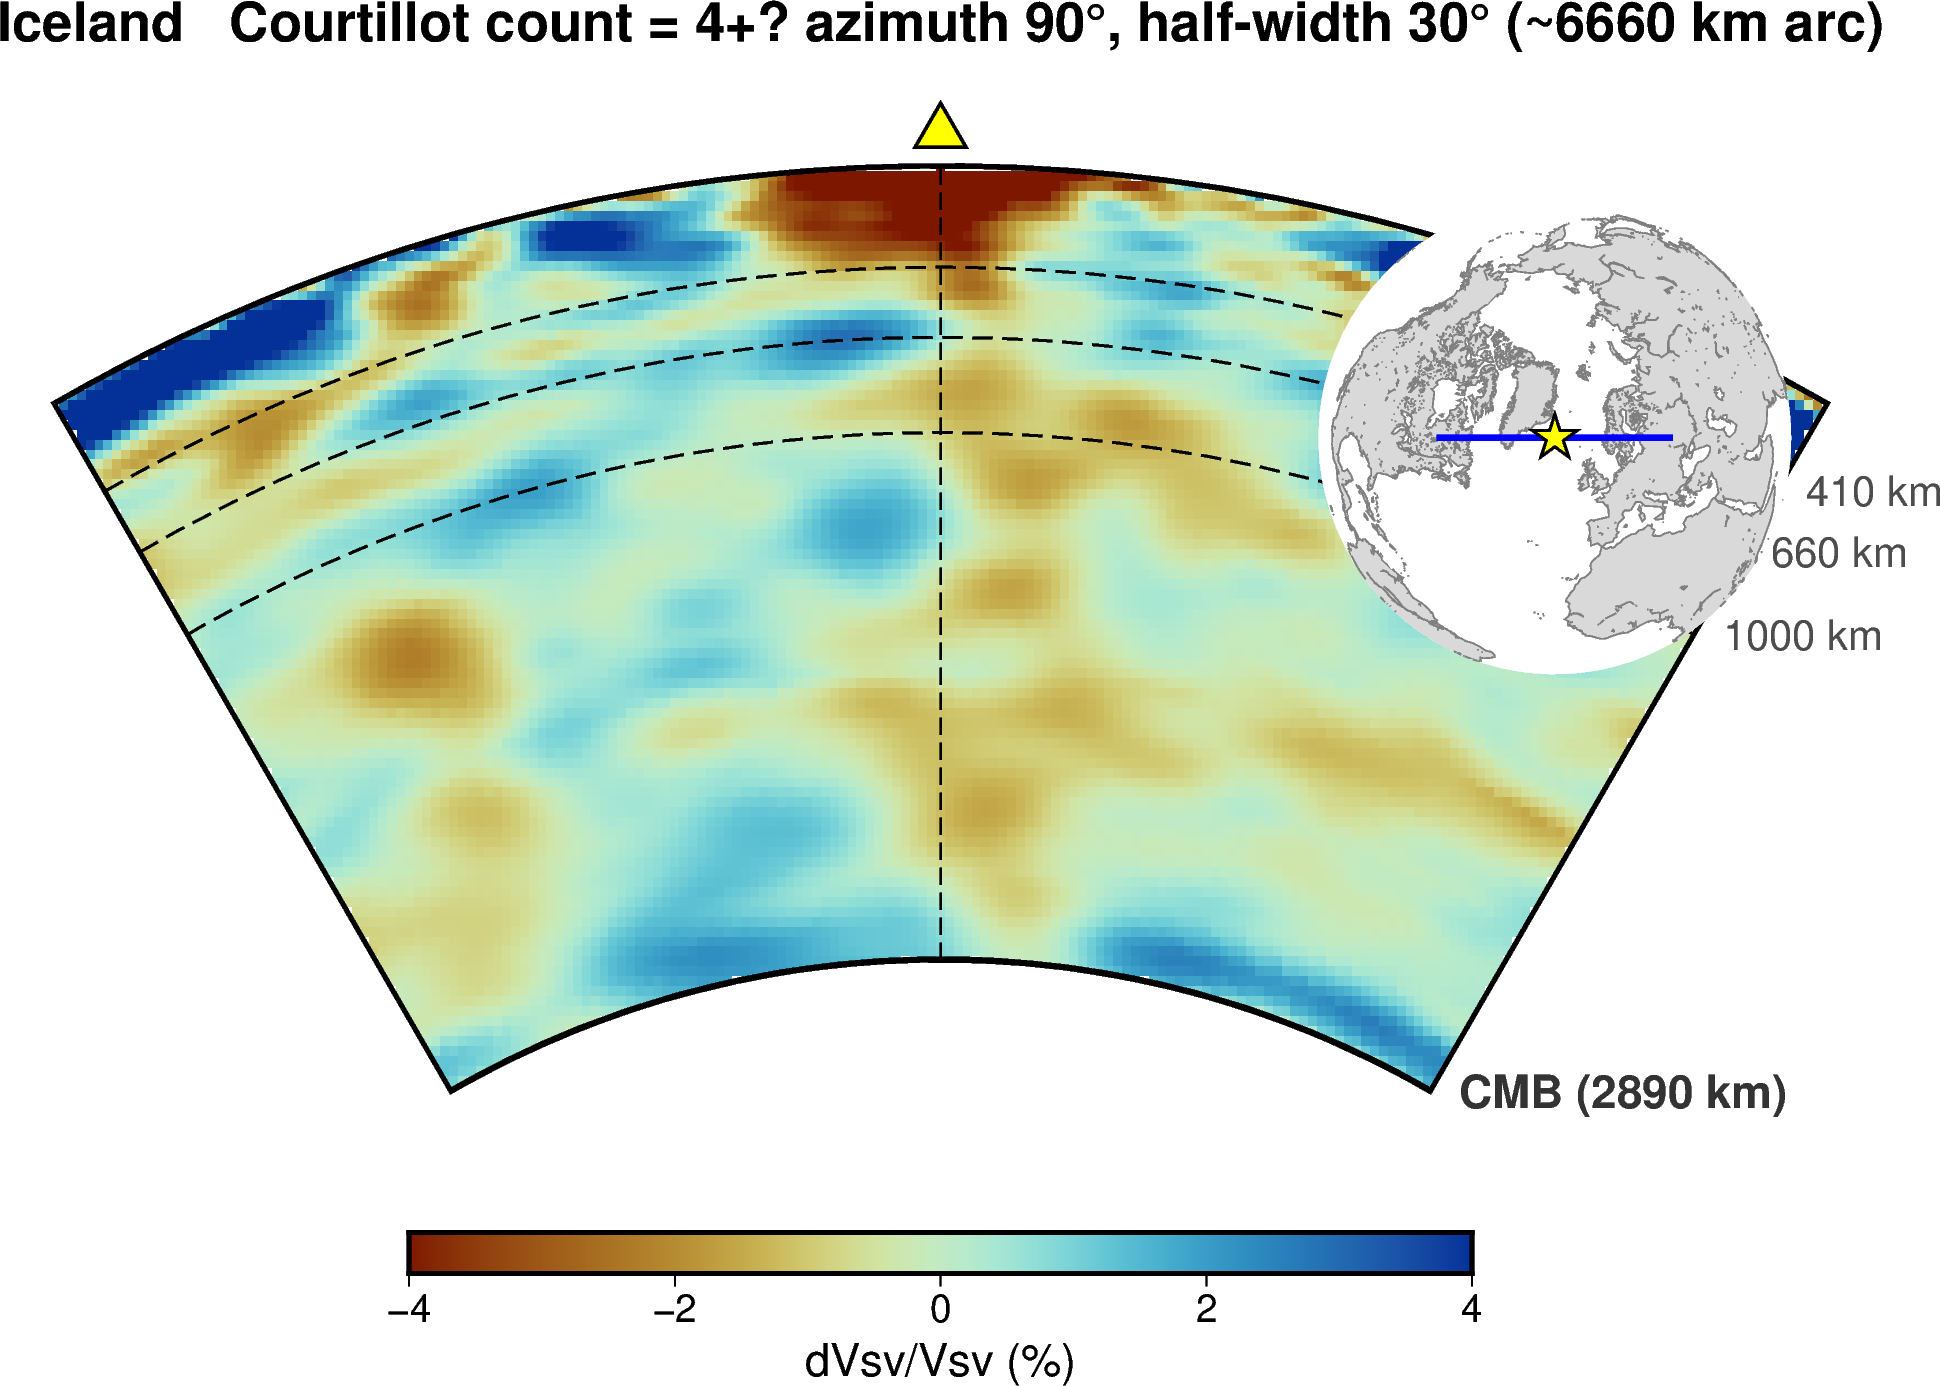

In [6]:
def cross_section_through(hotspot_name: str, azimuth_deg: float = AZIMUTH_DEG,
                            half_width_deg: float = HALF_WIDTH_DEG,
                            n: int = N_PATH_POINTS) -> tuple[xr.DataArray, np.ndarray, np.ndarray, pd.Series]:
    matches = hot.loc[hot["hotspot"].str.lower() == hotspot_name.lower()]
    if matches.empty:
        raise ValueError(f"hotspot {hotspot_name!r} not found in Courtillot table. "
                          f"Try one of: {hot['hotspot'].tolist()[:10]} ...")
    row = matches.iloc[0]
    lon_c = float(row["lon_180"]); lat_c = float(row["lat"])
    path_lons, path_lats = great_circle_path(lon_c, lat_c, azimuth_deg, half_width_deg, n)
    anom = sample_anomaly_along_path(ds_reveal, path_lons, path_lats, v_mean_depth)
    return anom, path_lons, path_lats, row


anom, path_lons, path_lats, row = cross_section_through(HOTSPOT_NAME)
fig = pygmt.Figure()
plot_wedge_cross_section(anom, row,
                          path_lons=path_lons, path_lats=path_lats,
                          fig=fig)
fig.show(width=1000)


## 5. Where the cross-section runs — locator map

Globe-projection map showing all candidate hotspots + the great-circle path of the just-rendered cross-section.

In [ ]:
fig_map = pygmt.Figure()
lon_c = float(row["lon_180"]); lat_c = float(row["lat"])
proj = f"G{lon_c}/{lat_c}/16c"
fig_map.basemap(region="d", projection=proj, frame=["af"])
# FAA gravity grid (Sandwell & Smith) as basemap. GMT auto-fetches the
# 6-arcmin global earth_faa grid on first use. Polar diverging cmap
# centred at 0 mGal; ±60 mGal saturation captures the bulk of the global
# signal (Hawaiian + Iceland + Ontong-Java swells ~+30-60, trenches as
# deep negatives, mid-ocean ridges with mixed signal).
pygmt.makecpt(cmap="roma", series=[-60, 60, 5], continuous=True)
fig_map.grdimage("@earth_faa_06m", region="d", projection=proj,
                  cmap=True, shading=True)
fig_map.coast(shorelines="0.4p,black", projection=proj)

# Background score-0/1 hotspots — tiny grey dots
fig_map.plot(x=background["lon_180"], y=background["lat"],
              style="c0.18c", fill="gray70", pen="0.3p,gray40")
# Ambiguous (count 2 or 3) hotspots — open white circles
fig_map.plot(x=ambiguous["lon_180"], y=ambiguous["lat"],
              style="c0.30c", fill="white", pen="1p,black")
# Primary (count 4) hotspots — filled red circles
fig_map.plot(x=primary["lon_180"], y=primary["lat"],
              style="c0.35c", fill="red3", pen="0.6p,black")
# Great-circle path of THIS cross-section — black line with a white halo
# (draw a fat white line first, then a thinner black line on top). The
# white halo makes the black line readable against any background colour
# in the roma gravity cpt.
fig_map.plot(x=path_lons, y=path_lats, pen="4p,white")
fig_map.plot(x=path_lons, y=path_lats, pen="1.5p,black")
# Highlight chosen hotspot — yellow star
fig_map.plot(x=[lon_c], y=[lat_c], style="a0.55c", fill="#FFFF00", pen="0.8p,black")
fig_map.text(x=[lon_c], y=[lat_c], text=[row["hotspot"]],
              font="12p,Helvetica-Bold,black",
              offset="0.4c/0.3c", fill="white", pen="0.4p,black")
fig_map.colorbar(cmap=True, position="JBC+w8c/0.35c+h+o0c/1.0c",
                  frame=["xa20f10+lFree-air gravity anomaly (mGal)"])
fig_map.show(width=900)


**Legend** for the locator map: background = free-air gravity anomaly (Sandwell & Smith satellite-altimetry-derived grid, auto-fetched by GMT via `@earth_faa_06m`). Hawaiian / Ontong-Java / Iceland swells stand out as broad gravity highs; trenches as deep gravity lows along subduction zones. Overlay symbols: grey small dots = score-0/1 hotspots (no plume evidence in Courtillot); open white circles = score-2/3 ambiguous hotspots; filled red circles = score-4 primary candidate deep plumes; yellow star = the hotspot the wedge above is sliced through; **white-haloed black line** = great-circle path of the cross-section.

## 6. Two cross-sections through the same plume — plumes are not radially symmetric

A single cross-section through a hotspot only shows you the plume *in that one plane*. Real mantle plumes are routinely tilted by mantle-wind entrainment and often broaden, narrow, or branch with depth — so the apparent geometry depends strongly on the azimuth you cut through. This cell renders **two perpendicular cross-sections** (90° apart in azimuth) through the same hotspot side-by-side, so you can see how the plume's depth profile varies with cut direction.

Vary `PAIR_HOTSPOT_NAME` to inspect different plumes. Iceland — sitting astride the Mid-Atlantic Ridge — is a good first look because cutting *across* the ridge (azimuth 90°) versus *along* the ridge (azimuth 0°/180°) tests directly whether the plume conduit is symmetric relative to the spreading axis. Other interesting cases:
- **Hawaii** — the textbook deep plume; conduit visible from surface to CMB
- **Yellowstone** — sometimes seen as tilted toward the SE by absolute plate motion
- **Tristan** — known to broaden in the lower mantle


In [ ]:
# Two perpendicular cross-sections through the SAME hotspot
PAIR_HOTSPOT_NAME = "Iceland"
PAIR_AZIMUTH_A    =  90.0   # E-W: across the Mid-Atlantic Ridge through Iceland
PAIR_AZIMUTH_B    = PAIR_AZIMUTH_A + 90.0   # perpendicular: N-S, along the ridge axis
PAIR_HALF_WIDTH   = 30.0

anom_a, lons_a, lats_a, row_a = cross_section_through(
    PAIR_HOTSPOT_NAME, azimuth_deg=PAIR_AZIMUTH_A, half_width_deg=PAIR_HALF_WIDTH)
anom_b, lons_b, lats_b, row_b = cross_section_through(
    PAIR_HOTSPOT_NAME, azimuth_deg=PAIR_AZIMUTH_B, half_width_deg=PAIR_HALF_WIDTH)

# House style: one pygmt.Figure() per panel. We show Panel A and Panel B as
# two separate figures; the second one carries a shared locator inset that
# shows BOTH great-circle paths (blue = azimuth A, red = azimuth B).
lon_c = float(row_a["lon_180"]); lat_c = float(row_a["lat"])

# Panel A
fig_a = pygmt.Figure()
plot_wedge_cross_section(anom_a, row_a, path_lons=lons_a, path_lats=lats_a,
                          azimuth_deg=PAIR_AZIMUTH_A,
                          half_width_deg=PAIR_HALF_WIDTH,
                          fig=fig_a, show_cbar=True, show_inset=False,
                          show_title="compact", wedge_width_cm=14.0)
# Two-path locator inset on panel A
with fig_a.inset(position="jTR+w4.5c+o0.3c/0.3c", box=None):
    fig_a.coast(region="d", projection=f"G{lon_c}/{lat_c}/4.5c",
                land="gray85", water="white", shorelines="0.3p,gray50")
    fig_a.plot(x=lons_a, y=lats_a, pen="2p,blue")
    fig_a.plot(x=lons_b, y=lats_b, pen="2p,red")
    fig_a.plot(x=[lon_c], y=[lat_c], style="a0.45c",
                fill="#FFFF00", pen="0.6p,black")
print(f"Panel A — {PAIR_HOTSPOT_NAME}, azimuth {PAIR_AZIMUTH_A:.0f}\260 (blue path):")
fig_a.show(width=900)

# Panel B
fig_b = pygmt.Figure()
plot_wedge_cross_section(anom_b, row_b, path_lons=lons_b, path_lats=lats_b,
                          azimuth_deg=PAIR_AZIMUTH_B,
                          half_width_deg=PAIR_HALF_WIDTH,
                          fig=fig_b, show_cbar=True, show_inset=False,
                          show_title="compact", wedge_width_cm=14.0)
with fig_b.inset(position="jTR+w4.5c+o0.3c/0.3c", box=None):
    fig_b.coast(region="d", projection=f"G{lon_c}/{lat_c}/4.5c",
                land="gray85", water="white", shorelines="0.3p,gray50")
    fig_b.plot(x=lons_a, y=lats_a, pen="2p,blue")
    fig_b.plot(x=lons_b, y=lats_b, pen="2p,red")
    fig_b.plot(x=[lon_c], y=[lat_c], style="a0.45c",
                fill="#FFFF00", pen="0.6p,black")
print(f"Panel B — {PAIR_HOTSPOT_NAME}, azimuth {PAIR_AZIMUTH_B:.0f}\260 (red path):")
fig_b.show(width=900)


### What this shows

The two wedges share the same hotspot at the top but differ in cut direction. If the plume conduit were a perfect radially symmetric column, both wedges would show the same depth profile of slow anomaly under the yellow triangle. In practice they don't — and the differences carry physical information:

- **Asymmetric vertical extent**: the conduit might be visible to the CMB in one cut but bottom out at mid-mantle in the perpendicular cut. This is a sign the conduit is *tilted* — the cut catches it on one side and misses on the other.
- **Different lateral width**: a plume head spreading under the lithosphere is highly anisotropic in plan view; cutting along the elongation direction versus across it gives very different patterns above \~300 km.
- **Branching / merging features**: some plumes (Iceland, Tristan) appear to split or merge with neighbouring slow features at depth — visible only when you cut at the right azimuth.

**Use this to choose a final azimuth** for your main cross-section in §4: scan a few cuts at 30° intervals around the hotspot to find the one that best captures the conduit's vertical extent before generating your prac-deliverable panels in §7.


## 7. The 8-hotspot deliverable (GEOS3101 prac)

Pick 8 hotspots from the count-2/3 list (or mix in a count-4 reference like Iceland or Hawaii), render a 2×4 panel comparison of wedge cross-sections. The default selection below covers a range of geographic and tectonic settings — edit `EIGHT_HOTSPOTS` to your own picks. Use `PER_HOTSPOT_AZIMUTH` if you want each panel's slice oriented for the local plume tilt or hotspot-track direction (defaults to the global `AZIMUTH_DEG` for all).

grdimage [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage (gmtapi_init_grdheader): Please select compatible -R and -I values


REVEAL vertical cross-sections through 8 Courtillot 'ambiguous' hotspots (score 2 or 3):
  azimuth 90°, half-width 30° (~6660 km arc)

  Bowie:


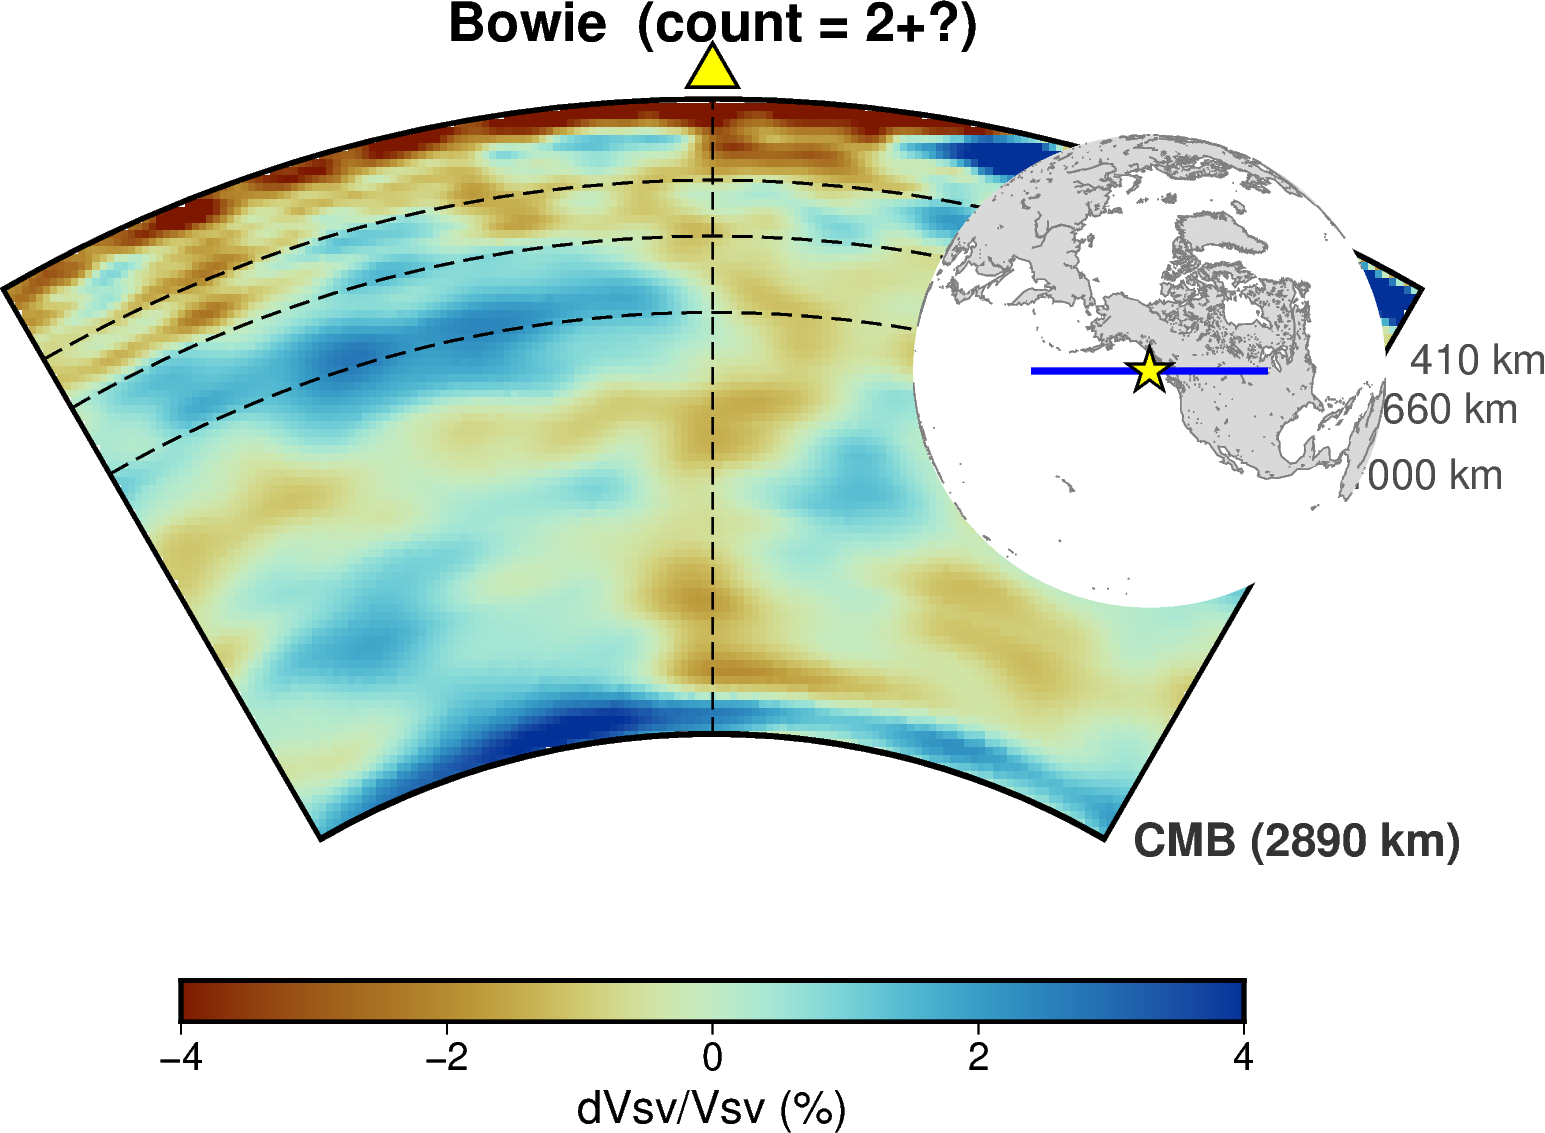

grdimage [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage (gmtapi_init_grdheader): Please select compatible -R and -I values


  Galapagos:


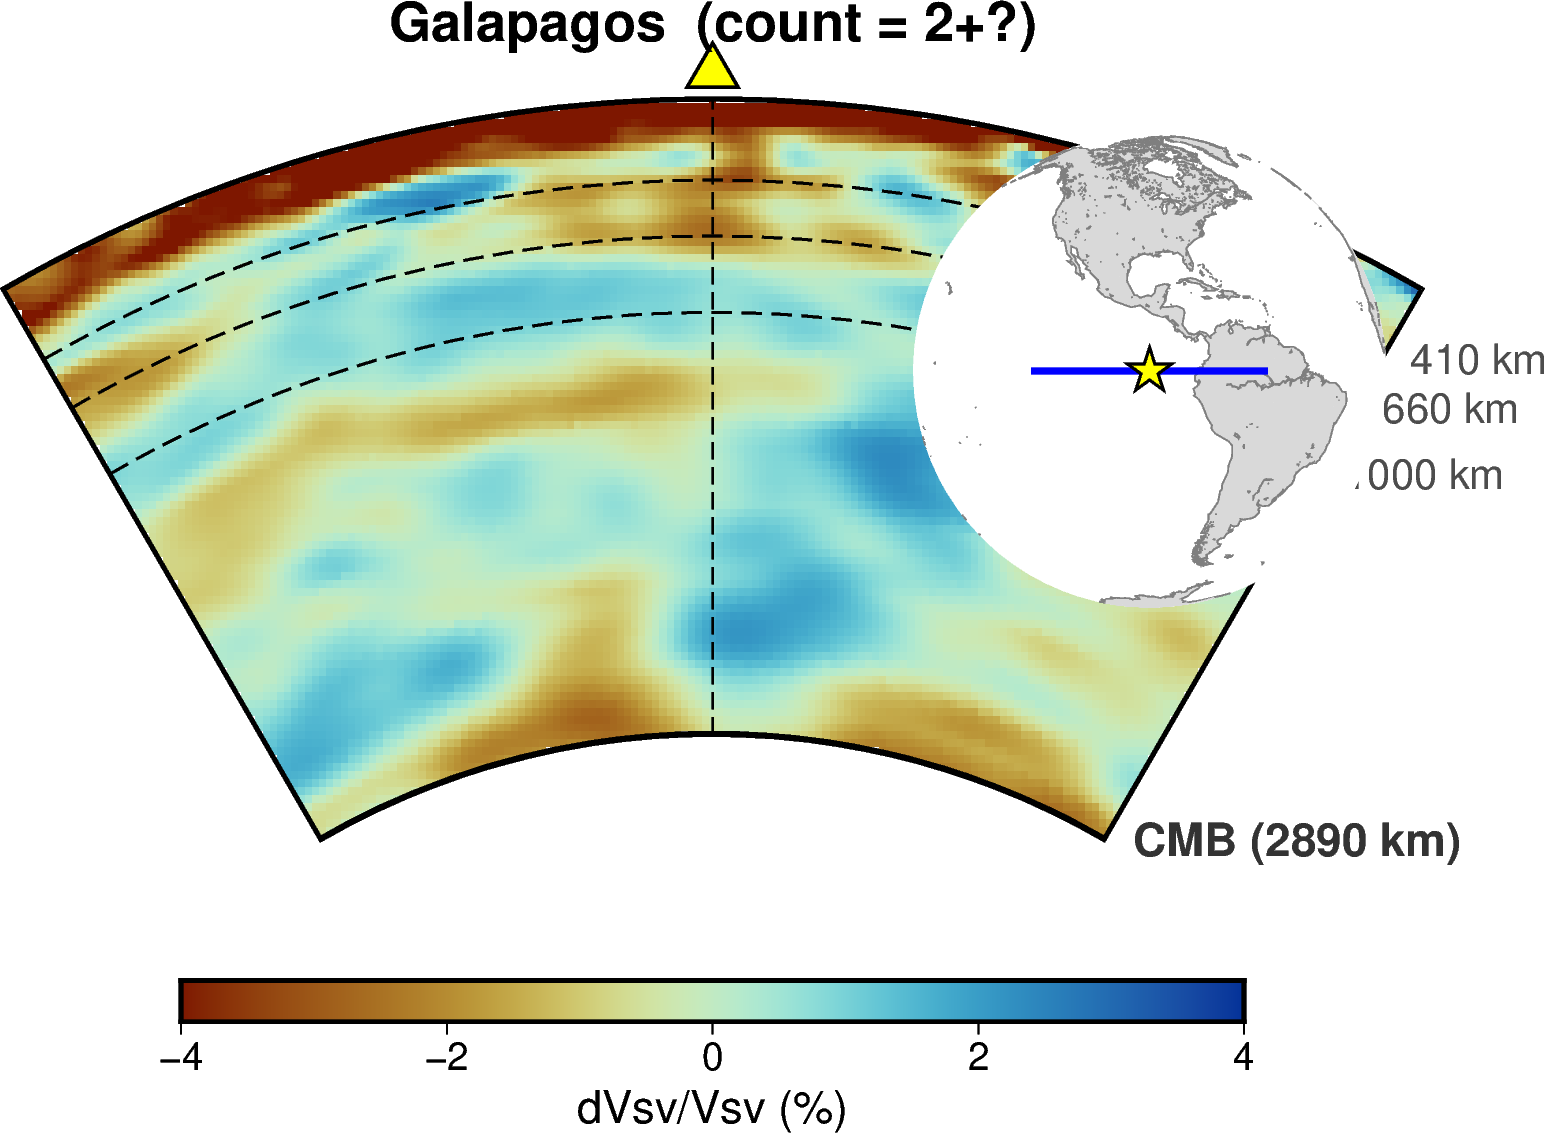

grdimage [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage (gmtapi_init_grdheader): Please select compatible -R and -I values


  Yellowstone:


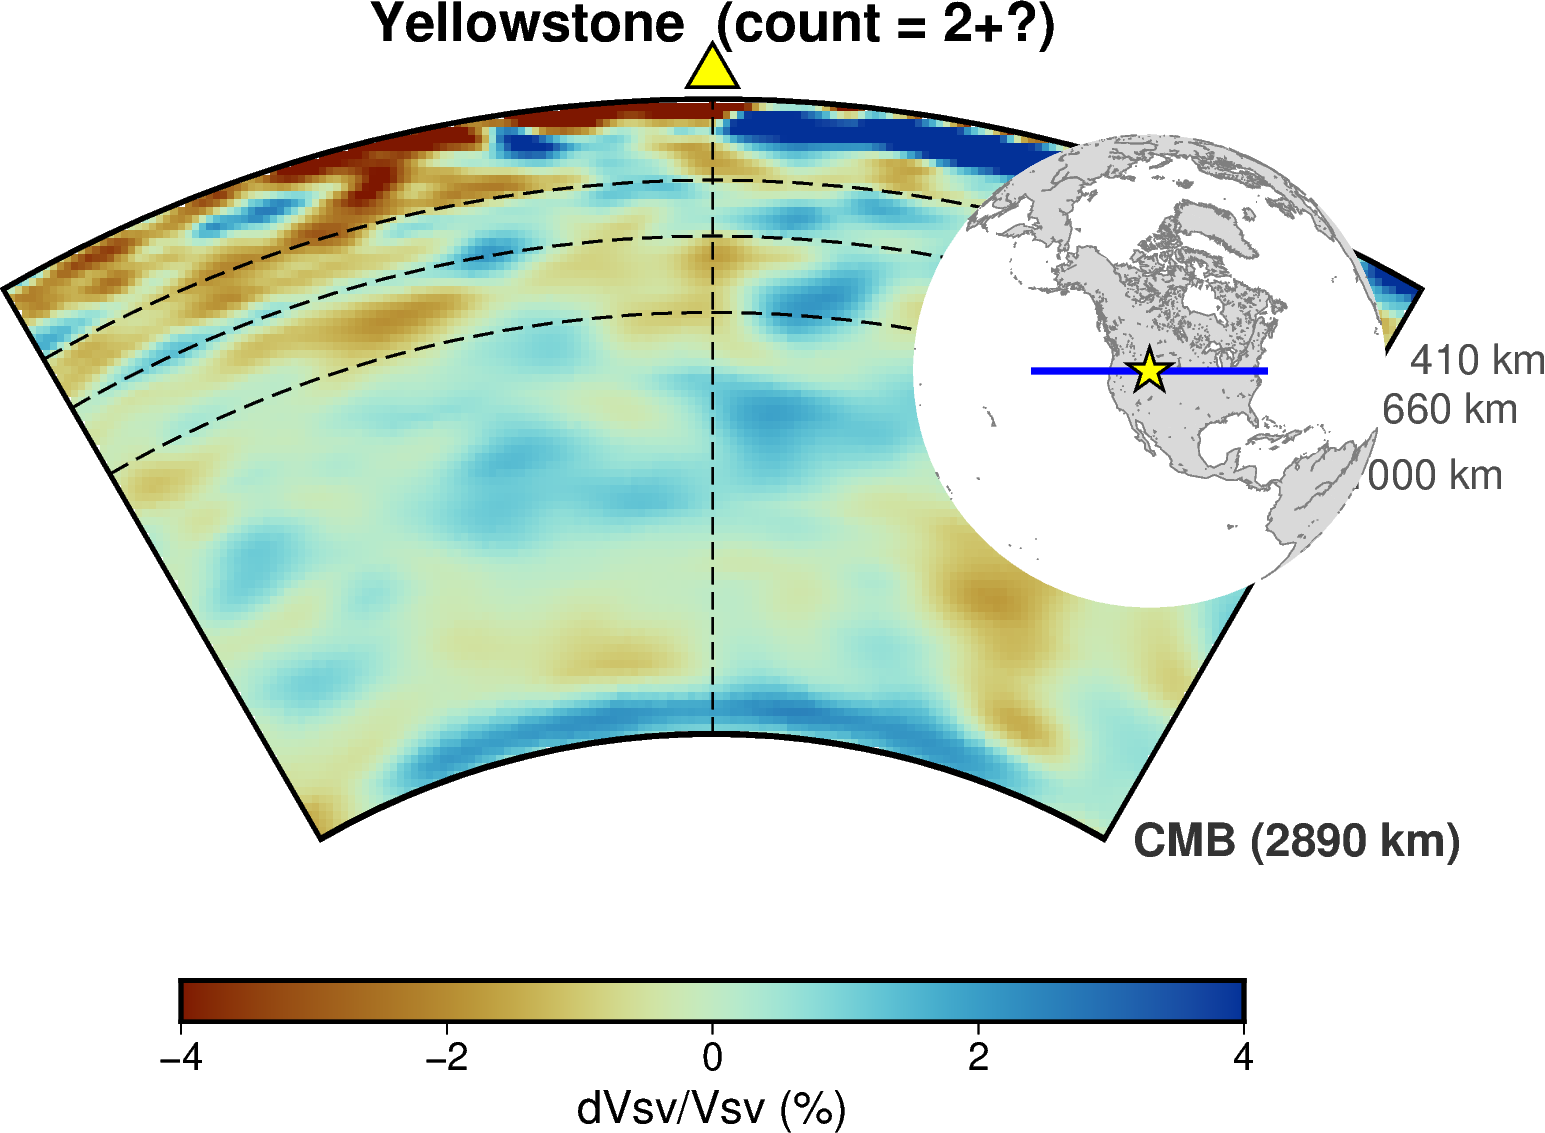

grdimage [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage (gmtapi_init_grdheader): Please select compatible -R and -I values


  Caroline:


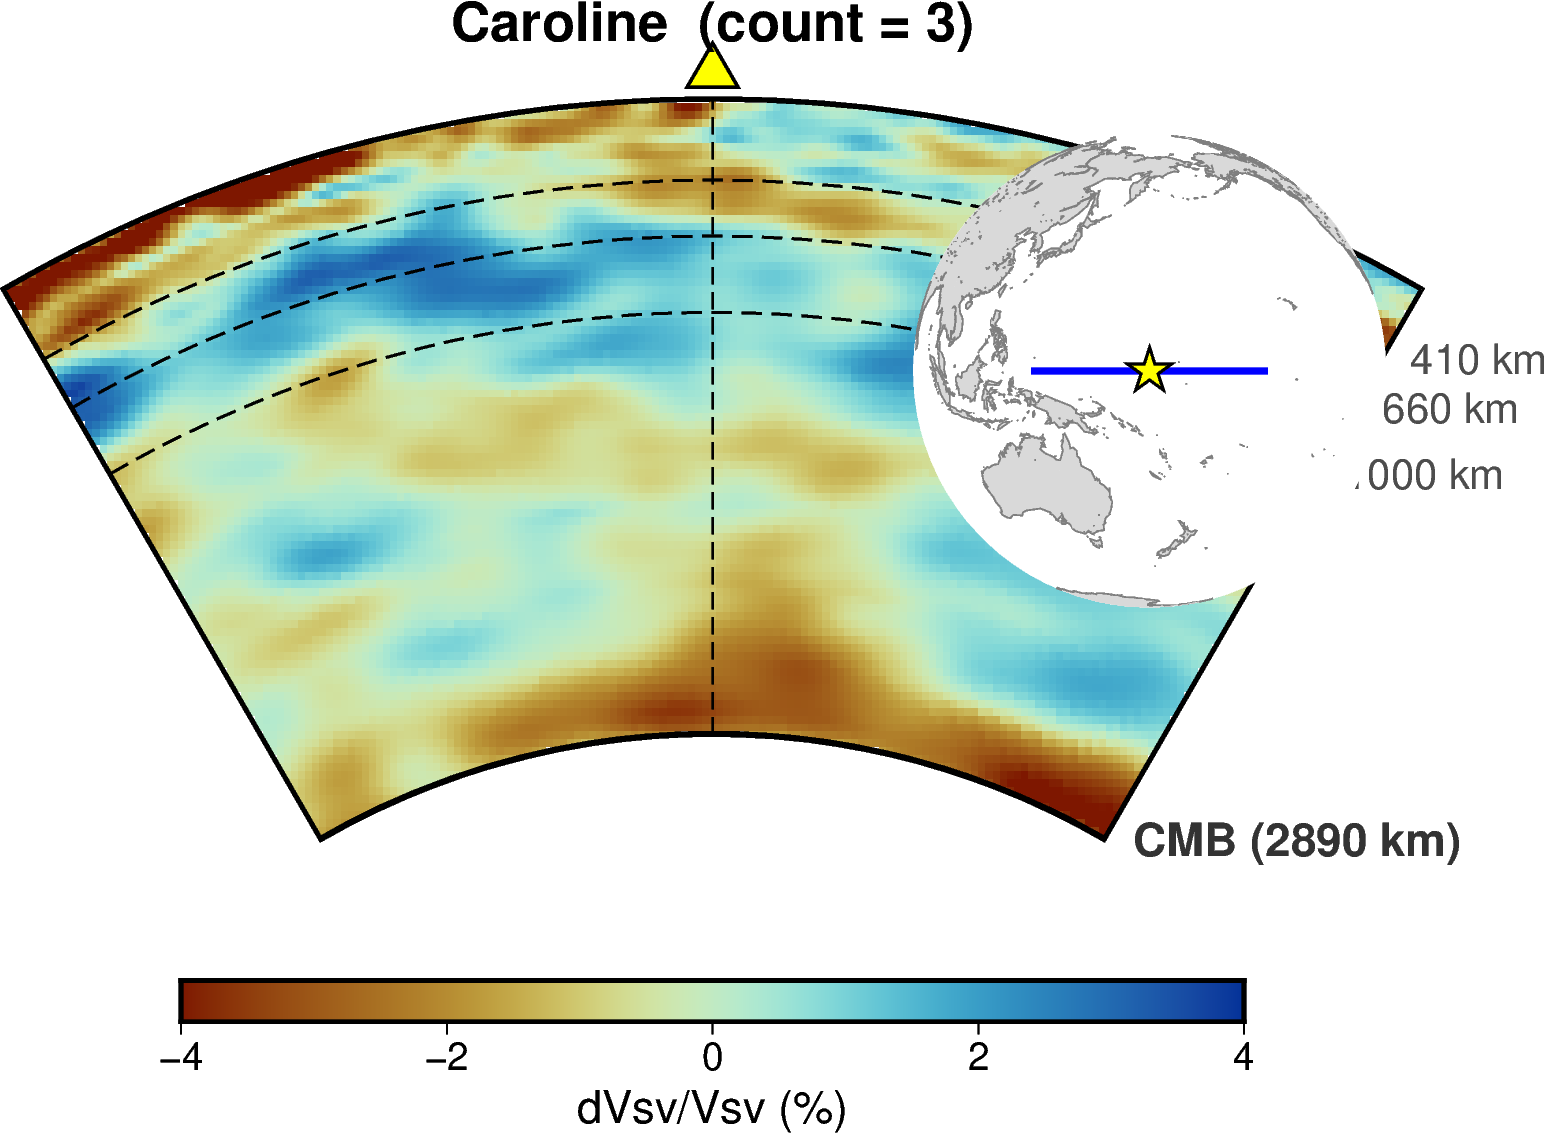

grdimage [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage (gmtapi_init_grdheader): Please select compatible -R and -I values


  Kerguelen(Heard):


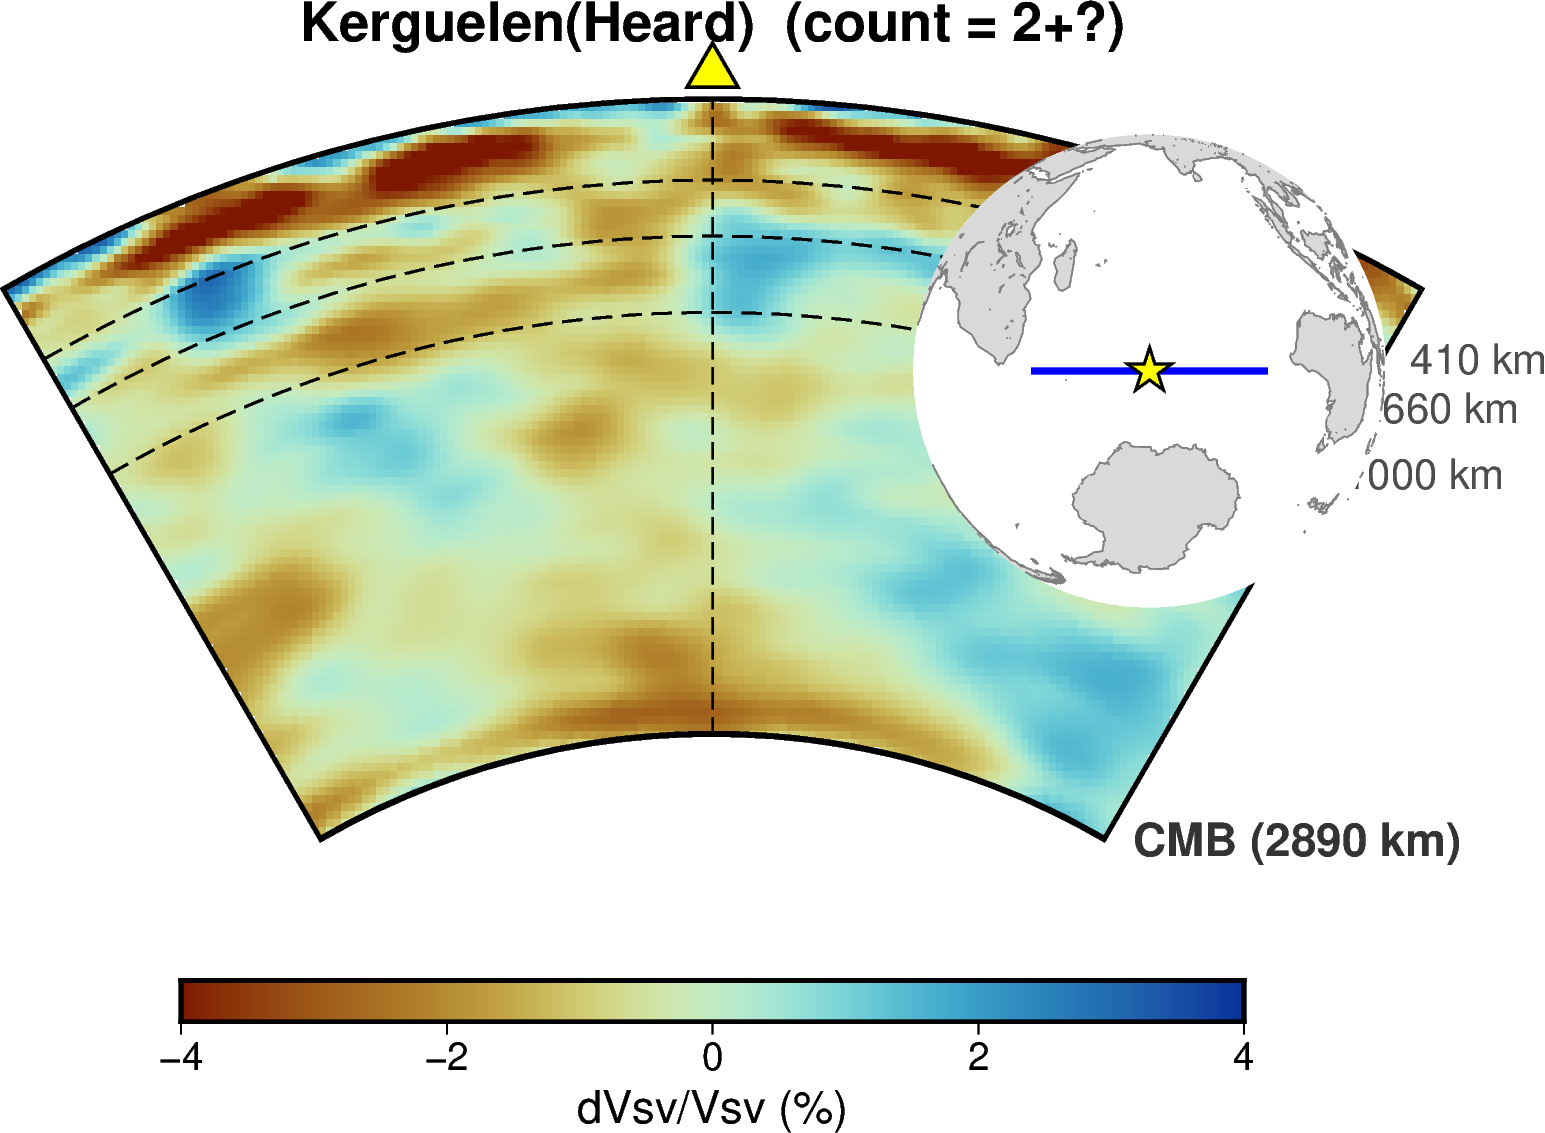

grdimage [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage (gmtapi_init_grdheader): Please select compatible -R and -I values


  Louisville:


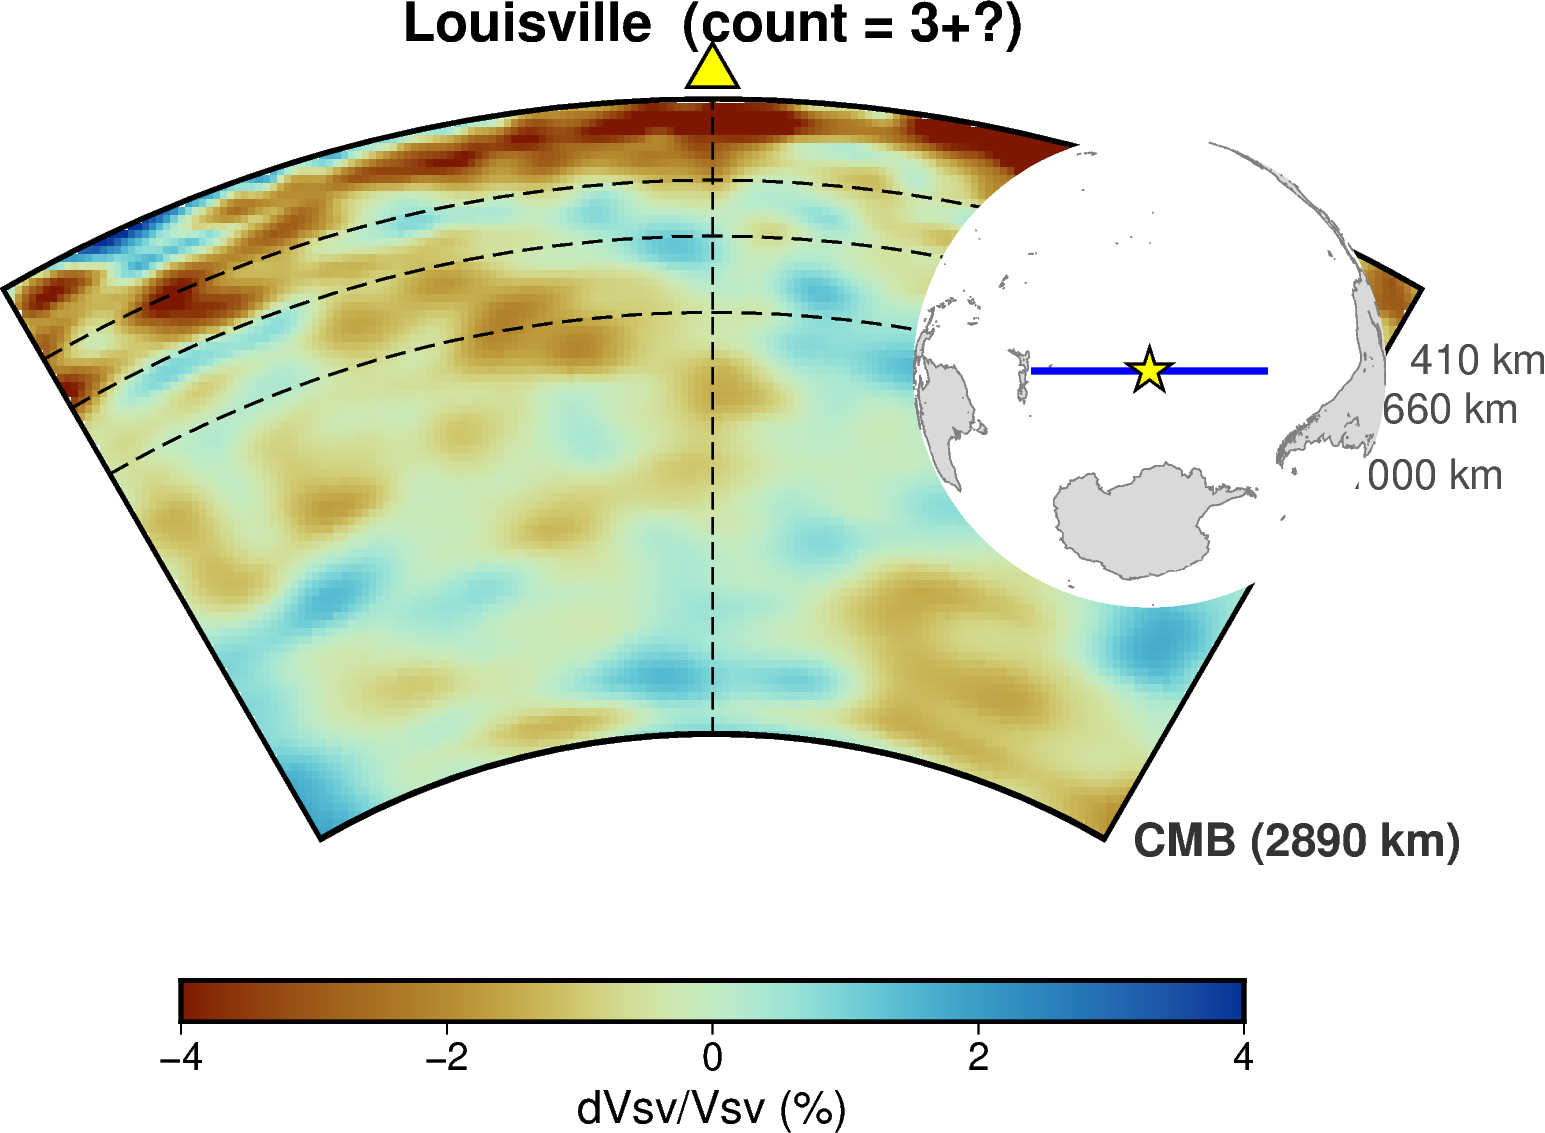

grdimage [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage (gmtapi_init_grdheader): Please select compatible -R and -I values


  Tristan:


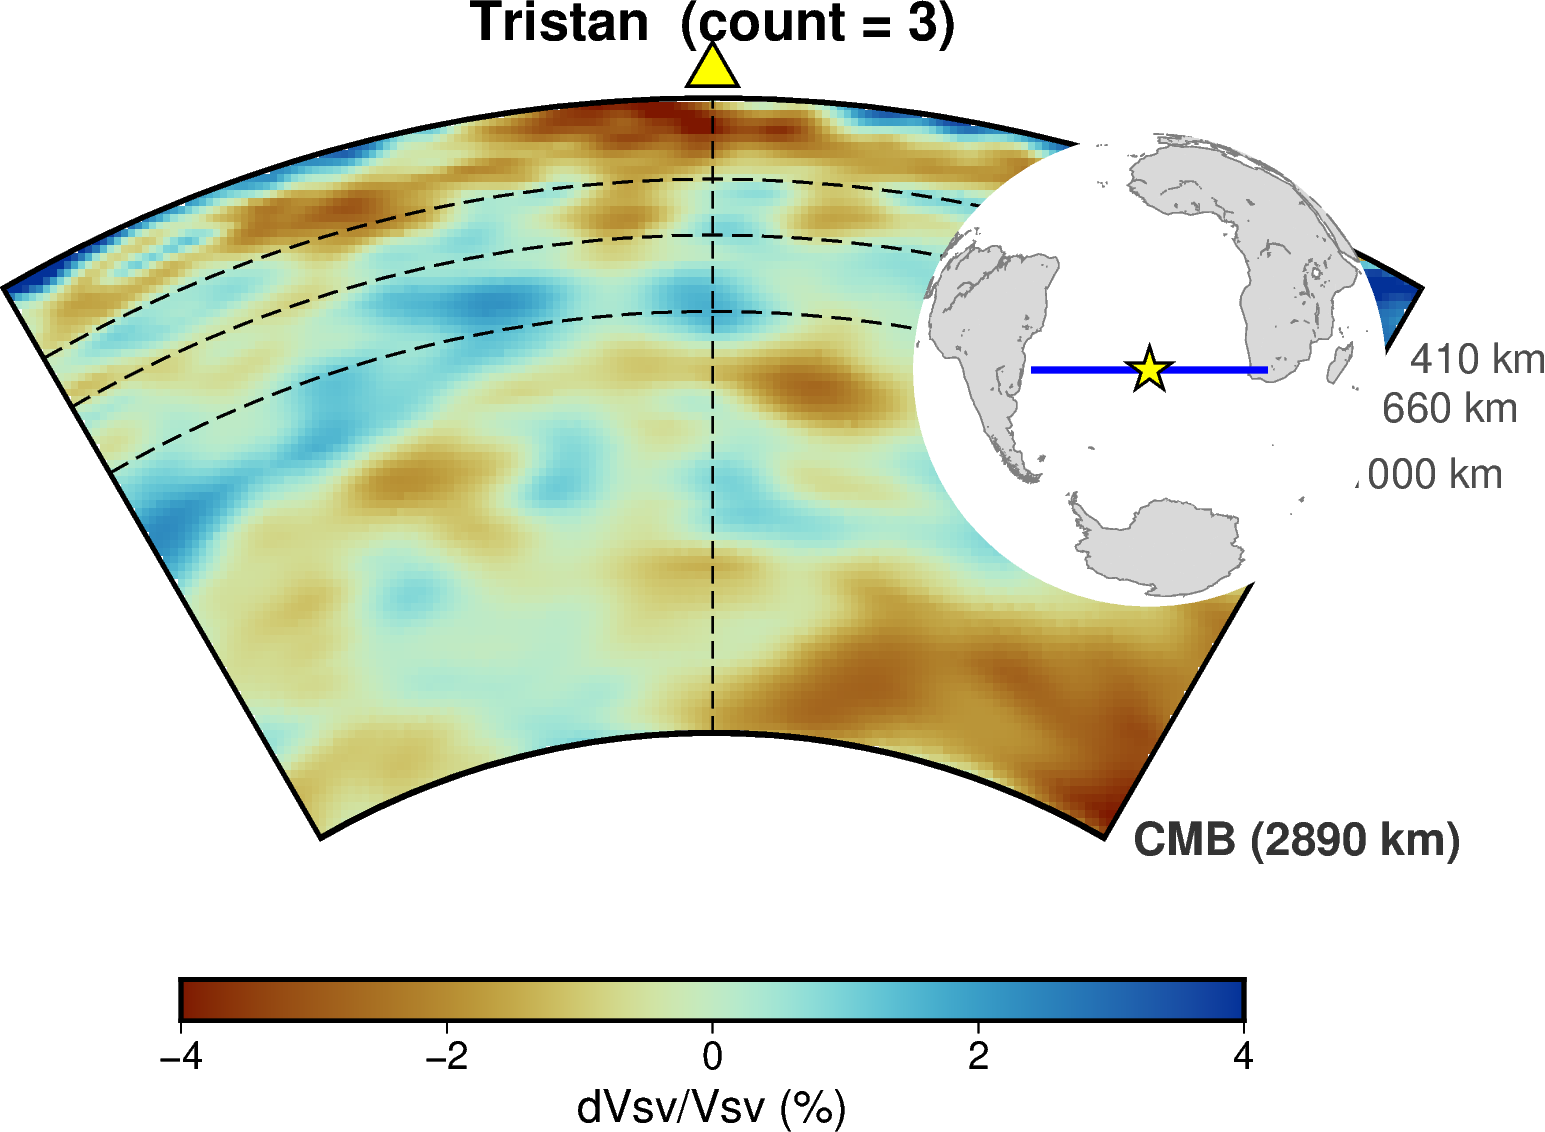

grdimage [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdimage (gmtapi_init_grdheader): Please select compatible -R and -I values


  Tahiti/Society:


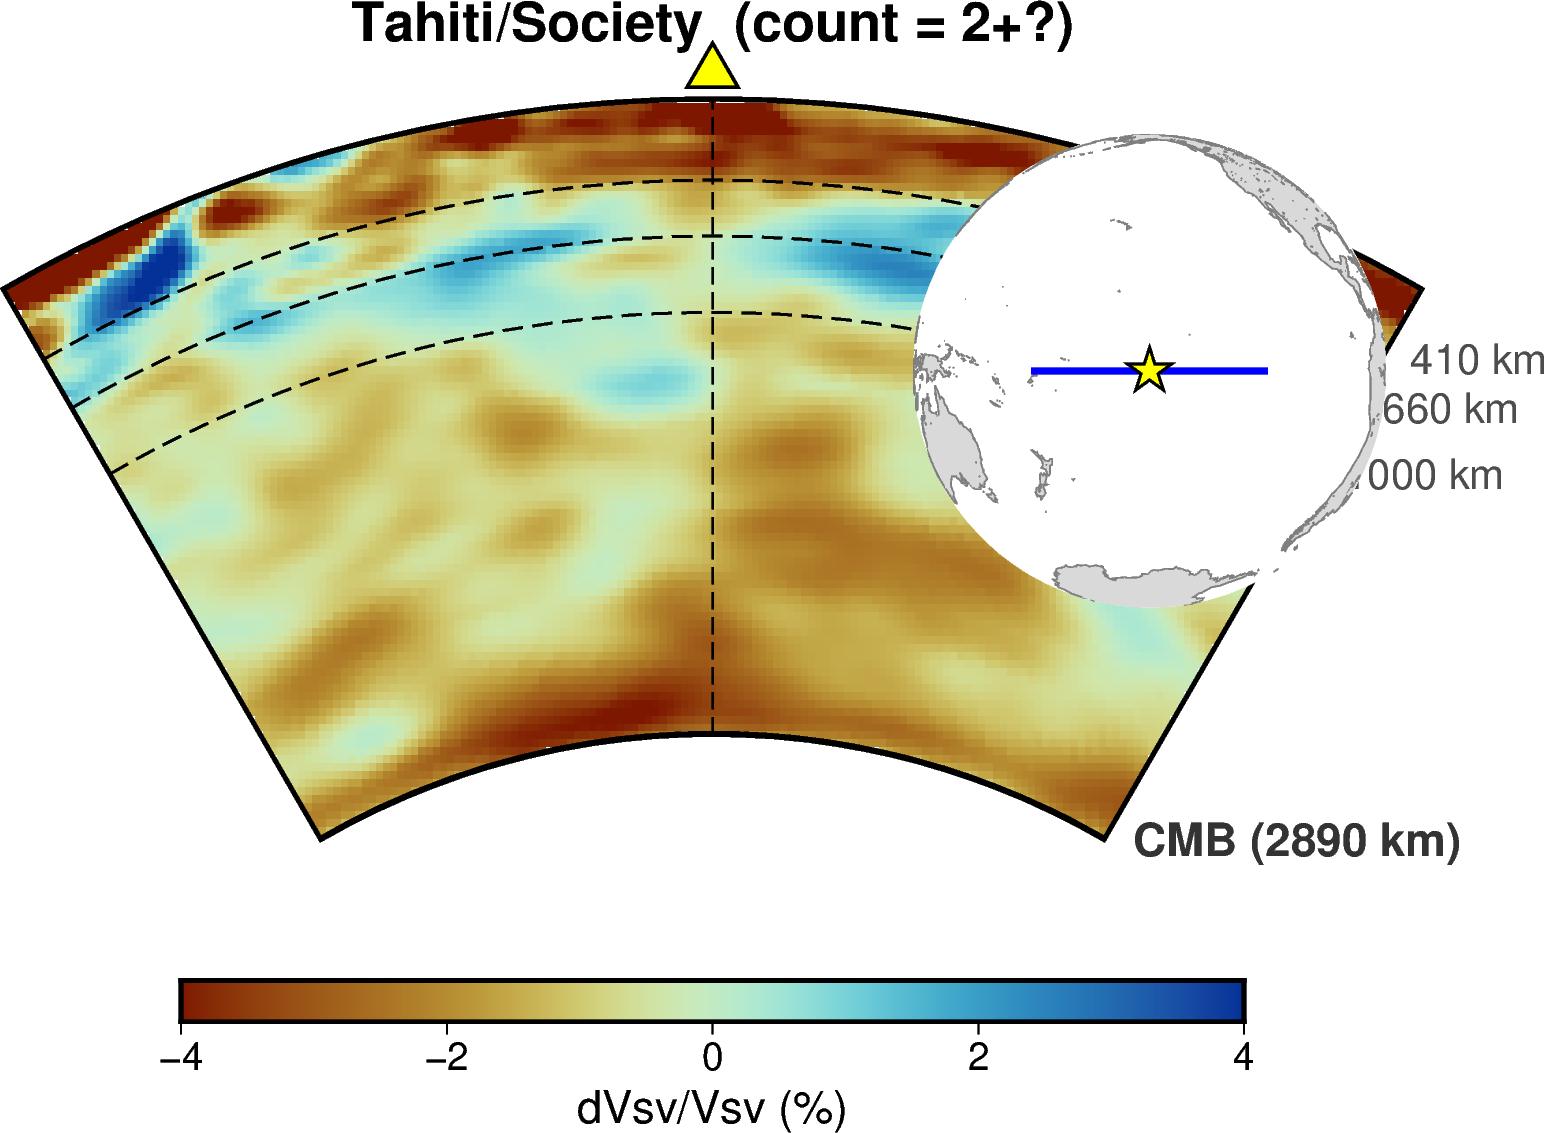

In [9]:
EIGHT_HOTSPOTS = [
    "Bowie",            # NE Pacific, near subduction
    "Galapagos",        # equatorial E Pacific
    "Yellowstone",      # continental, North America
    "Caroline",         # W Pacific
    "Kerguelen(Heard)", # S Indian Ocean
    "Louisville",       # SW Pacific
    "Tristan",          # S Atlantic
    "Tahiti/Society",   # central Pacific
]
# Override per-hotspot if you want each slice oriented differently. Examples:
#   "Yellowstone":  65    (along the Snake River-Yellowstone track)
#   "Hawaii":      120    (along the Hawaii-Emperor chain)
PER_HOTSPOT_AZIMUTH = {h: AZIMUTH_DEG for h in EIGHT_HOTSPOTS}

# House style: one pygmt.Figure() per panel. Emit 8 independent wedge
# figures, each with its own compact colourbar + locator inset, shown in
# sequence at moderate width so the whole set browses cleanly on GitHub.
print(f"REVEAL vertical cross-sections through 8 Courtillot 'ambiguous' "
      f"hotspots (score 2 or 3):\n"
      f"  azimuth {AZIMUTH_DEG:.0f}\260, half-width {HALF_WIDTH_DEG:.0f}\260 "
      f"(~{2 * HALF_WIDTH_DEG * 111:.0f} km arc)\n")

for hn in EIGHT_HOTSPOTS:
    try:
        anom_i, lons_i, lats_i, row_i = cross_section_through(
            hn, azimuth_deg=PER_HOTSPOT_AZIMUTH[hn])
        fig_i = pygmt.Figure()
        plot_wedge_cross_section(anom_i, row_i,
                                  path_lons=lons_i, path_lats=lats_i,
                                  azimuth_deg=PER_HOTSPOT_AZIMUTH[hn],
                                  fig=fig_i, show_cbar=True, show_inset=True,
                                  show_title="compact", wedge_width_cm=12.0)
        print(f"  {hn}:")
        fig_i.show(width=700)
    except Exception as e:
        print(f"  {hn}: FAILED — {e}")


### Interpreting the 8-panel comparison

For each wedge, ask:

1. **Is there a coherent slow (red) column under the yellow triangle?** If yes, trace it downward.
2. **What's its bottom depth?** Does it bottom out at the 410-km dashed arc (transition-zone-limited), at 660 km (post-spinel-stalled), at \~1000 km (mid-mantle-stalled — Dong et al. 2025), or does it continue to the inner arc at 2890 km (deep plume)?
3. **Is the conduit vertical, or does it tilt?** Tilt suggests entrainment by the large-scale mantle wind. Try re-running cell 4 with a different `AZIMUTH_DEG` to align the cross-section with the tilt direction.
4. **Are there any blue columns?** A deep blue patch is a slab graveyard, not a plume — Courtillot's criteria explicitly avoid these.

**Compare with a count-4 reference**: re-run cell 4 with `HOTSPOT_NAME = "Iceland"` (or `"Hawaii"`, `"Réunion"`, `"Easter"`, `"Samoa"`, `"Afar"`) to see what a textbook deep plume looks like under REVEAL. Iceland is the configured default and shows a broad slow anomaly straddling the Mid-Atlantic Ridge with mid-mantle structure; Hawaii in particular shows a strong slow conduit from the surface to a CMB-anchored ultra-low velocity zone.


## 8. The hotspot in paleo-geographic context — LIPs, volcanic chains, and a synthetic hotspot track

So far we've cut REVEAL vertically through the chosen hotspot (`HOTSPOT_NAME`) to look at the *present-day* mantle structure beneath it. To turn that snapshot into a deep-time story we need to ask: **where has this hotspot been over the last 130 Myr, and does its track line up with a coherent series of progressively older volcanic structures at the surface?**

This section adds the GPlately / pygplates piece. On a single orthographic globe centred on the chosen hotspot we render:

- **Faint free-air gravity** background (Sandwell & Smith satellite altimetry), so the modern ocean-basin context (swells, ridges, trenches) is visible without dominating the figure.
- **Continental outlines and present-day coastlines** from the suite's default Zahirovic 2022 plate model.
- **Plate boundaries** drawn with the continuous-backbone pattern (all topological sections as a grey backbone, then ridges in red, transforms in goldenrod, trenches in black with subduction teeth).
- **Johansson et al. (2018) Large Igneous Provinces and volcanic chains** for 0–130 Ma, colour-coded by their begin age — **pink = young (0 Ma), blue = old (130 Ma)**.
- **A synthetic hotspot track** at 10-Myr intervals back to 130 Ma under the *fixed-hotspot + fixed-plate* assumption.

The data source for the volcanic provinces is:

> Johansson, L., Zahirovic, S., & Müller, R. D. (2018). The interplay between the eruption and weathering of Large Igneous Provinces and the deep-time carbon cycle. *Geophysical Research Letters* 45, https://doi.org/10.1029/2017GL076691

The bundled file `data/LIPS_volcanic_chains/Johansson_etal_2018_VolcanicProvinces_v2.gpmlz` contains 2526 LIP polygons spanning the whole Phanerozoic; we filter to the 0–130 Ma window (Cretaceous-and-younger, ≈1590 features) so the colour scale spans the lifetime of the synthetic track.

In [10]:
# Load Johansson et al. (2018) LIPs/volcanic chains and filter to 0-130 Ma.
# Each feature carries a `valid_time = (begin_age, end_age)` — we keep
# those whose begin_age is at or younger than 130 Ma (i.e. they exist
# somewhere in the window the synthetic hotspot track covers).
import pygplates
from shapely.geometry import Polygon

LIP_PATH = Path("data/LIPS_volcanic_chains/Johansson_etal_2018_VolcanicProvinces_v2.gpmlz")
if not LIP_PATH.exists():
    raise FileNotFoundError(
        f"LIP feature collection not found at {LIP_PATH}. The Johansson "
        "2018 .gpmlz file ships with this tutorial suite under "
        "data/LIPS_volcanic_chains/. Run Jupyter from the project root.")

LIP_AGE_MAX = 130.0
_lip_features_all = pygplates.FeatureCollection(str(LIP_PATH))
lip_records = []   # list of (age_ma, [(lon, lat), ...]) for each polygon
for _feat in _lip_features_all:
    _vt = _feat.get_valid_time(None)
    if _vt is None:
        continue
    _begin, _end = _vt
    if _begin > LIP_AGE_MAX:
        continue
    # A single feature can hold one or several geometries; iterate all.
    for _geom in _feat.get_geometries():
        if not isinstance(_geom, pygplates.PolygonOnSphere):
            continue
        _coords = [(lon, lat) for lat, lon in _geom.to_lat_lon_list()]
        if len(_coords) < 3:
            continue
        lip_records.append((float(_begin), _coords))

print(f"  loaded {len(_lip_features_all)} total LIP features from "
      f"Johansson et al. 2018")
print(f"  retained {len(lip_records)} polygon geometries with begin_age "
      f"<= {LIP_AGE_MAX:.0f} Ma")
print(f"  age range of retained polygons: "
      f"{min(r[0] for r in lip_records):.0f} - "
      f"{max(r[0] for r in lip_records):.0f} Ma")


  loaded 2526 total LIP features from Johansson et al. 2018
  retained 1611 polygon geometries with begin_age <= 130 Ma
  age range of retained polygons: 0 - 130 Ma


### Synthetic hotspot track — computing where the surface volcano was at each past age

Under the **fixed-hotspot** hypothesis (Morgan 1971) the hotspot is anchored in the mantle frame at a single point, and the plate slides over it. The conduit therefore "writes" a surface track on the plate(s) above it as those plates move past. To draw the track on a present-day basemap, we need, for every past age `t`, the *present-day* location of the plate-point that was directly above the hotspot at time `t`.

The computation has three layers, all using the suite's default Zahirovic 2022 rotation model + topologies:

1. **Plate at the hotspot at each age** — scan the topology at `TRACK_RESOLUTION_MYR` cadence (default 1 Myr) using `pygplates.resolve_topologies` filtered to closed-plate-boundary polygons only, and record which plate ID contains the hotspot at each age. When the plate ID changes between adjacent times, we have a *plate-boundary crossing*; we bisect down to \~0.1 Myr to pin its exact age, and we filter out spurious crossings where the two plates have identical present-day rotations (rigid attachment expressed as different IDs).

2. **Forward stage-rotation integration** — for each anchor age, take the plate-point that was at the hotspot at that age and walk it forward to present day via 1-Myr stage-rotation steps, re-resolving the plate it currently belongs to at every step. This is the geologically correct treatment: a plate-point can transfer between plates when a rifting event splits its host plate into two (e.g. NE-Atlantic opening at \~55 Ma splits Greenland 102 from Eurasia 301), and its post-split motion belongs to whichever sub-plate it ended up on — not the pre-split parent plate's full finite rotation.

3. **Segment grouping for display** — the resulting present-day positions are grouped into segments by the plate that was at the hotspot at the anchor age, so the rendered track can be colour-coded by plate when desired. The track itself is geometrically continuous (no jumps at boundary crossings) because the forward-integration handles plate transfers continuously.


In [11]:
# Step 1: load the Zahirovic 2022 rotation model + static polygons via the
# plate-model manager. We use the same model as cluster A/B notebooks
# (suite default) so the track is consistent with what T05, T06, T07 etc.
# would show. This bypasses the existing notebook's per-cell setup because
# T33 itself is a present-day tomography notebook and didn't previously
# need a PlateReconstruction — we add one here purely for the track work.
import gplately
from plate_model_manager import PlateModelManager
import bisect

PLATE_MODEL_FOR_TRACK = "Zahirovic2022"
ANCHOR_PLATE_ID       = 0

# === USER CONFIGURATION — synthetic-track sampling =========================
# TRACK_CADENCE_MYR controls how often we plant a marker along each segment
# (default 10 Myr; reduce for fast plates like the Pacific so the chain is
# resolved). TRACK_RESOLUTION_MYR controls the FINE grid used ONLY to detect
# plate-boundary crossings (default 1 Myr; finer = more accurate crossing
# times, but more pygplates topology resolutions). TRACK_MAX_AGE_MA is how
# far back to compute the synthetic track.
TRACK_CADENCE_MYR    = 10.0
TRACK_RESOLUTION_MYR =  1.0
TRACK_MAX_AGE_MA     = 130.0
# ============================================================================

_pmm   = PlateModelManager()
_model = _pmm.get_model(PLATE_MODEL_FOR_TRACK, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model   = _model.get_rotation_model(),
    topology_features= _model.get_topologies(),
    static_polygons  = _model.get_static_polygons(),
    anchor_plate_id  = ANCHOR_PLATE_ID,
)
rotation_model = recon.rotation_model

# Step 2: set up the hotspot point. The hotspot is fixed in the MANTLE
# frame: the same (lat, lon) for all time. What CAN change is which plate
# is currently passing over the hotspot — plate boundaries migrate over
# the (mantle-fixed) hotspot location and the hotspot transitions from
# being on plate A to plate B. We scan the topology at TRACK_RESOLUTION_MYR
# to detect those crossings, then bisect to ~0.1 Myr to pin the exact
# crossing time, then sample each segment at TRACK_CADENCE_MYR. The row
# variable was set in section 4 by cross_section_through(HOTSPOT_NAME);
# reuse it here.
hotspot_lon = float(row["lon_180"])
hotspot_lat = float(row["lat"])
hotspot_pt  = pygplates.PointOnSphere(hotspot_lat, hotspot_lon)

def _load_features(arg):
    """Coerce a PMM-style return value (str path / list of paths /
    already-loaded Feature(Collection) / iterable thereof) into a flat
    list of pygplates.Feature objects. PMM versions vary in what they
    return from get_topologies() / get_static_polygons(); this helper
    handles all of them."""
    if arg is None:
        return []
    if isinstance(arg, str):
        return list(pygplates.FeatureCollection(arg))
    if isinstance(arg, (list, tuple)):
        out = []
        for item in arg:
            out.extend(_load_features(item))
        return out
    try:
        return list(arg)
    except TypeError:
        return [arg]

topology_features = _load_features(_model.get_topologies())

# Plate-id → plate-name cache, populated as a side effect of
# plate_id_at_hotspot() — the name comes from the topological plate
# feature the resolver found, NOT from any static polygon set.
_pid_to_name = {}

def _plate_id_at_position(pt, time_ma: float) -> int:
    """Resolve the closed-plate-boundary network at time_ma and return
    the plate ID of the polygon containing `pt`. We filter
    `resolve_topology_types=ResolveTopologyType.boundary` so the
    resolved set is a true partition of the sphere (one polygon per
    point, no overlapping deforming networks or topological lines).
    The plate name is read from the topology feature itself and cached
    in _pid_to_name for pname()."""
    resolved_topologies = []
    pygplates.resolve_topologies(
        topology_features, rotation_model,
        resolved_topologies, float(time_ma),
        resolve_topology_types=pygplates.ResolveTopologyType.boundary,
    )
    for rt in resolved_topologies:
        polygon = rt.get_resolved_boundary()
        if polygon and polygon.is_point_in_polygon(pt):
            feat = rt.get_feature()
            pid  = feat.get_reconstruction_plate_id()
            _pid_to_name[pid] = feat.get_name() or "?"
            return pid
    return -1


def plate_id_at_hotspot(time_ma: float) -> int:
    """Plate at the (mantle-frame fixed) hotspot location at time_ma.
    Thin wrapper around _plate_id_at_position(hotspot_pt, ...)."""
    return _plate_id_at_position(hotspot_pt, time_ma)


def _forward_integrate_to_present(start_time_ma: float,
                                    stage_step_myr: float = 1.0):
    """Walk a plate-point that was at the hotspot mantle-frame location
    at start_time_ma FORWARD in time to present day, via piece-wise
    concatenation of STAGE rotations (NOT a single finite rotation),
    re-resolving the plate the point is currently on at every step.

    At each stage_step_myr step:
      1. Resolve topology at the point's CURRENT mantle-frame position
         at the CURRENT age — the plate-point belongs to whichever
         plate now occupies that location.
      2. Apply that plate's STAGE rotation from t → t-step (forward in
         time = t decreases).
      3. Update the point's position and decrement t.

    This is the geologically correct treatment. Consider a plate-point
    at the Iceland hotspot at 85 Ma: per Z22 topology it is on the
    102+301 rigidly-attached body. Between 55 and 0 Ma (after NE-
    Atlantic opening) the point may end up on plate 102 alone, in
    which case its 55→0 Ma motion is 102's, NOT 301's. Using a single
    85→0 finite rotation on 301 conflates the pre- and post-rift eras
    and yields a wrong present-day position. Forward integration with
    stage rotations + plate re-resolution at each step handles the
    rifting transition correctly.

    Returns (lon, lat, history) where history is a list of (t, pid)
    pairs showing which plate the point was on at each step. Returns
    (None, None, []) if the integration falls off a well-defined plate
    (incomplete topology at some intermediate age).
    """
    pos = hotspot_pt
    t = float(start_time_ma)
    history = []
    last_known_pid = -1
    gap_count = 0
    while t > 1e-6:
        t_next = max(0.0, t - stage_step_myr)
        pid = _plate_id_at_position(pos, t)
        if pid < 0:
            # Topology gap at this step — fall back to last-known plate
            # ID. Z22 topologies have small coverage holes at boundary
            # transitions; we assume the point hasn't actually left its
            # plate. If no plate has ever been resolved (gap at t=start),
            # bail.
            if last_known_pid < 0:
                return None, None, history
            pid = last_known_pid
            gap_count += 1
        else:
            last_known_pid = pid
        history.append((t, pid))
        # Stage rotation of `pid` from time t to time t_next.
        # Forward in time means t > t_next; the rotation describes "where
        # the plate went from t to t_next" and applied to a plate-point
        # on `pid` at time t gives its position at time t_next.
        stage_rot = rotation_model.get_rotation(
            to_time         = t_next,
            moving_plate_id = pid,
            from_time       = t,
            anchor_plate_id = ANCHOR_PLATE_ID,
        )
        pos = stage_rot * pos
        t = t_next
    lat, lon = pos.to_lat_lon()
    return float(lon), float(lat), history

def pname(pid: int) -> str:
    """Format a plate-id + name from the side-effect _pid_to_name cache
    populated by plate_id_at_hotspot(). The name is the one carried by
    the topological plate feature (NOT from any static polygon set)."""
    return f"{pid} ({_pid_to_name.get(pid, '?')})"


def _present_day_position_diff_deg(pid_a: int, pid_b: int,
                                    time_ma: float) -> float:
    """Return the angular distance (degrees) between the present-day
    positions of two plate-points: one on plate pid_a, one on plate
    pid_b, both originally at the hotspot's mantle-frame location at
    time_ma. If the two plates are rigidly attached at time_ma (no
    relative motion through to present), this distance is ~0. If they
    diverged (different rotation paths from time_ma → 0), the distance
    measures the disagreement.

    Used to filter false-positive plate-boundary crossings: when the
    topology resolver finds a different plate ID at time t (boundary
    migrating across the hotspot), but the two plates have identical
    rotations from t → 0, the "crossing" is a topology-only artifact
    (rigid attachment expressed as separate plate IDs) and should not
    introduce a jump in the synthetic track.
    """
    import numpy as _np_p
    r_a = rotation_model.get_rotation(
        to_time=0, moving_plate_id=pid_a, from_time=float(time_ma),
        anchor_plate_id=ANCHOR_PLATE_ID,
    )
    r_b = rotation_model.get_rotation(
        to_time=0, moving_plate_id=pid_b, from_time=float(time_ma),
        anchor_plate_id=ANCHOR_PLATE_ID,
    )
    pos_a = r_a * hotspot_pt
    pos_b = r_b * hotspot_pt
    la, lo_a = pos_a.to_lat_lon()
    lb, lo_b = pos_b.to_lat_lon()
    phi1 = _np_p.radians(la); phi2 = _np_p.radians(lb)
    a = (_np_p.sin((phi2 - phi1) / 2) ** 2 +
         _np_p.cos(phi1) * _np_p.cos(phi2) *
         _np_p.sin(_np_p.radians(lo_b - lo_a) / 2) ** 2)
    return float(_np_p.degrees(2 * _np_p.arcsin(_np_p.sqrt(min(1.0, a)))))


# Tolerance (degrees) for treating a crossing as a no-motion artifact.
# 1.0° ≈ 111 km on the surface — well below any real plate-motion-jump
# scale but loose enough to not be tripped up by numerical noise.
NO_MOTION_CROSSING_TOL_DEG = 1.0

# Step 3: fine-grid plate-id lookup over the full window. plate_id_at_hotspot
# resolves the dynamic topological plate polygons (NOT static polygons)
# at each requested time. This is where we detect crossings that the
# coarser TRACK_CADENCE_MYR would miss.
fine_times = list(np.arange(0.0,
                             TRACK_MAX_AGE_MA + TRACK_RESOLUTION_MYR / 2,
                             TRACK_RESOLUTION_MYR))
fine_pids  = [plate_id_at_hotspot(t) for t in fine_times]

# Step 4: detect transitions (consecutive different plate IDs) and bisect
# down to ~0.1 Myr to pin the crossing time for each one.
transitions = []   # list of (t_before, plate_before, t_after, plate_after, t_crossing)
for _i in range(len(fine_times) - 1):
    if fine_pids[_i] != fine_pids[_i + 1]:
        lo, hi = fine_times[_i], fine_times[_i + 1]
        lo_pid, hi_pid = fine_pids[_i], fine_pids[_i + 1]
        while hi - lo > 0.1:
            mid = 0.5 * (lo + hi)
            mid_pid = plate_id_at_hotspot(mid)
            if mid_pid == lo_pid:
                lo = mid
            else:
                hi = mid
                hi_pid = mid_pid
        t_cross = 0.5 * (lo + hi)
        transitions.append((fine_times[_i], fine_pids[_i],
                            fine_times[_i + 1], fine_pids[_i + 1], t_cross))

# Step 4b: FILTER OUT no-motion crossings. When the topology resolver
# detects a boundary crossing at t_cross — going from plate A to plate B
# — but the two plates have IDENTICAL rotations from t_cross → 0 (i.e.
# they were rigidly attached at t_cross, before any later separation),
# the "crossing" is a topology-only artifact, not a real motion change.
# It would otherwise produce a spurious JUMP in the synthetic track
# because plate A and plate B can have different composite rotation
# paths in the rotation tree even when they were a single rigid body
# at t_cross.
_real_transitions = []
_filtered = 0
for (_lo, _lo_pid, _hi, _hi_pid, t_cross) in transitions:
    _diff_deg = _present_day_position_diff_deg(_lo_pid, _hi_pid, t_cross)
    if _diff_deg < NO_MOTION_CROSSING_TOL_DEG:
        print(f"  [filter] {t_cross:.2f} Ma: {pname(_lo_pid)} ↔ {pname(_hi_pid)} "
              f"give present-day positions only {_diff_deg:.3f}° apart "
              f"(< {NO_MOTION_CROSSING_TOL_DEG:.1f}° tol) → rigidly attached at "
              f"this age, NOT a real motion-jump → segments merged")
        _filtered += 1
    else:
        _real_transitions.append((_lo, _lo_pid, _hi, _hi_pid, t_cross))
print(f"  [filter] {_filtered} no-motion transition(s) filtered; "
      f"{len(_real_transitions)} real motion-jump transition(s) retained")

# Step 5: build contiguous segment intervals from the REAL transitions
# only. Each segment occupies a single plate over [t_start, t_end].
# Adjacent segments share the transition time t_cross — that point
# appears in BOTH the segment that ends at it (computed with the
# "before" plate's rotation) AND the segment that starts at it
# (computed with the "after" plate's rotation).
segment_intervals = []   # list of (t_start, t_end, plate_id)
prev_t = 0.0
prev_pid = fine_pids[0]
for (_lo, _lo_pid, _hi, _hi_pid, t_cross) in _real_transitions:
    segment_intervals.append((prev_t, t_cross, prev_pid))
    prev_t = t_cross
    prev_pid = _hi_pid
segment_intervals.append((prev_t, TRACK_MAX_AGE_MA, prev_pid))

# Step 6: for each segment, sample at TRACK_CADENCE_MYR cadence plus the
# segment start + end times so adjacent segments touch. Each sample's
# present-day position is computed via FORWARD STAGE-ROTATION INTEGRATION
# from time t to 0, with the plate re-resolved at every 1-Myr step. This
# correctly handles plate-point transfers across rifting events that no
# single-finite-rotation approach can capture.
segments = []
for (t_start, t_end, pid) in segment_intervals:
    inner = list(np.arange(
        np.ceil(t_start / TRACK_CADENCE_MYR) * TRACK_CADENCE_MYR,
        t_end - 1e-6, TRACK_CADENCE_MYR))
    times_for_seg = [t_start] + [t for t in inner if t > t_start + 1e-6] + [t_end]
    times_for_seg = sorted(set(round(t, 6) for t in times_for_seg))
    pts = []
    _failed = []
    for t in times_for_seg:
        # Forward-integrate the plate-point that was at the hotspot at
        # time t, all the way to present day, switching plates as the
        # topology evolves (see _forward_integrate_to_present docstring).
        # This is the CORRECT computation — it handles the case where
        # a rifting event (e.g. NE-Atlantic opening at ~55 Ma) leaves
        # the plate-point on a different sub-plate after the rift, so
        # its post-rift motion belongs to that other plate's stage
        # rotations, NOT the pre-rift parent plate's finite rotation.
        lon, lat, _hist = _forward_integrate_to_present(float(t))
        if lon is not None:
            pts.append((t, pid, lon, lat))
        else:
            _failed.append(t)
    if _failed:
        print(f"    ⚠ segment plate {pid}: integration failed for "
              f"{len(_failed)} time(s): {[f'{t:.1f}' for t in _failed]} Ma "
              f"(topology gap)")
    segments.append(pts)

# Step 7: clear report of the boundary detection so the user knows what
# happened sub-cadence.
print(f"\n=== Synthetic hotspot track for {HOTSPOT_NAME} "
      f"({hotspot_lon:.1f}, {hotspot_lat:.1f}) ===")
print(f"  cadence = {TRACK_CADENCE_MYR:.0f} Myr  |  boundary-detection "
      f"resolution = {TRACK_RESOLUTION_MYR:.1f} Myr")
print(f"  back to {TRACK_MAX_AGE_MA:.0f} Ma")
print(f"  ✓ {len(transitions)} plate-boundary crossing(s) detected "
      f"(scanning at {TRACK_RESOLUTION_MYR:.1f}-Myr cadence; bisected to ~0.1 Myr):")
if len(transitions) == 0:
    print(f"    (the hotspot stayed on plate {pname(fine_pids[0])} for the whole "
          f"{TRACK_MAX_AGE_MA:.0f}-Myr window)")
for (lo, lo_pid, hi, hi_pid, t_cross) in transitions:
    print(f"    between {lo:5.1f} Ma and {hi:5.1f} Ma → plate changes from "
          f"{pname(lo_pid)} to {pname(hi_pid)}")
    print(f"       bisected exact crossing at {t_cross:5.2f} Ma")
print(f"  {len(segments)} track segment(s):")
for _i, (_seg, (_ts, _te, _spid)) in enumerate(zip(segments, segment_intervals),
                                                  start=1):
    if not _seg:
        print(f"    segment {_i}: plate {pname(_spid)} | "
              f"times {_ts:.1f}–{_te:.1f} Ma | (no points — all "
              f"integrations failed due to topology gaps)")
        continue
    _pid = _seg[0][1]
    print(f"    segment {_i}: plate {pname(_pid)} | "
          f"times {_seg[0][0]:.1f}–{_seg[-1][0]:.1f} Ma | "
          f"{len(_seg)} points")

# Step 8: per-point printout so the user can read off the track
# positions numerically alongside the rendered map in the next cell.
print("\n  per-point track positions (present-day lon, lat):")
for _i, _seg in enumerate(segments, start=1):
    if not _seg:
        continue
    _pid = _seg[0][1]
    print(f"    segment {_i} (plate {pname(_pid)}):")
    for (_t, _, _lo, _la) in _seg:
        print(f"      {_t:6.2f} Ma → lon = {_lo:+8.2f}°, lat = {_la:+6.2f}°")


  [filter] 4.84 Ma: 301 (Eurasia EUR_080_078) ↔ 101 (NAM) give present-day positions only 0.833° apart (< 1.0° tol) → rigidly attached at this age, NOT a real motion-jump → segments merged
  [filter] 32.03 Ma: 101 (NAM) ↔ 102 (Greenland) give present-day positions only 0.000° apart (< 1.0° tol) → rigidly attached at this age, NOT a real motion-jump → segments merged
  [filter] 2 no-motion transition(s) filtered; 4 real motion-jump transition(s) retained
    ⚠ segment plate 301: integration failed for 1 time(s): ['10.0'] Ma (topology gap)
    ⚠ segment plate 301: integration failed for 1 time(s): ['10.0'] Ma (topology gap)

=== Synthetic hotspot track for Iceland (-20.0, 65.0) ===
  cadence = 10 Myr  |  boundary-detection resolution = 1.0 Myr
  back to 130 Ma
  ✓ 6 plate-boundary crossing(s) detected (scanning at 1.0-Myr cadence; bisected to ~0.1 Myr):
    between   4.0 Ma and   5.0 Ma → plate changes from 301 (Eurasia) to 101 (NAM_4-0Ma)
       bisected exact crossing at  4.84 Ma
    b

### The map

Layering (bottom to top):

1. Faint free-air gravity background (75% transparent so it's visible but doesn't dominate).
2. Present-day continental outlines + coastlines.
3. Continuous plate-boundary backbone, then styled ridges/transforms/trenches with subduction teeth.
4. Johansson 2018 LIPs/chains, fill colour mapped to begin age via the reversed `cool` cpt (pink for young, blue for old).
5. Synthetic hotspot track as a thick white-haloed black line with filled circles every 10 Myr.
6. Present-day hotspot position as a yellow star, matching the locator-map style of §5.

The age colour bar at the bottom is drawn so that the WYSIWYG reading is *pink → blue from left to right*, i.e. **0 Ma → 130 Ma**. This is the *reverse* of the deep-time convention (where blue normally means young and red means old); the choice was made to keep the youngest LIPs visually distinct from the oldest while leaving the conventional warm-tone "active" semantics for the hotspot star itself.

In [ ]:
# Render the orthographic globe centred on the chosen hotspot.
import gplately
from gplately import PygmtPlotEngine

fig_geo = pygmt.Figure()
_proj = f"G{hotspot_lon}/{hotspot_lat}/16c"

# (1) Basemap frame
fig_geo.basemap(region="d", projection=_proj, frame=["af"])

# (2) Faint FAA gravity background. Use the same roma cpt + 6-arcmin grid
# as the locator map in section 5; here transparency=75 dims the signal
# to ~25% opacity so the LIP colours sit cleanly on top.
pygmt.makecpt(cmap="roma", series=[-60, 60, 5], continuous=True)
fig_geo.grdimage("@earth_faa_06m", region="d", projection=_proj,
                  cmap=True, transparency=75)

# (3) Present-day continental outlines + coastlines from Zahirovic 2022.
# We attach a PlotTopologies at time=0 because the LIP polygons are
# stored in their present-day positions in this dataset.
gplot = gplately.PlotTopologies(
    plate_reconstruction = recon,
    coastlines           = _model.get_coastlines(),
    continents           = _model.get_continental_polygons(),
    COBs                 = _model.get_COBs(),
    time                 = 0.0,
    plot_engine          = PygmtPlotEngine(),
)
gplot.plot_coastlines(fig_geo, pen="0.4p,gray20")

# (4) Continuous plate-boundary backbone, then styled ridges / transforms
#     / trenches with subduction teeth.
gplot.plot_all_topological_sections(fig_geo, pen="0.5p,gray50")
gplot.plot_ridges(fig_geo, pen="0.8p,red")
gplot.plot_transforms(fig_geo, pen="0.8p,goldenrod")
gplot.plot_trenches(fig_geo, pen="0.8p,black")
gplot.plot_subduction_teeth(fig_geo, color="black")

# (5) Johansson 2018 LIPs/chains, age-coloured 0-130 Ma.
# Reversed `cool` cpt: matplotlib's `cool` is cyan-to-magenta, so
# reversed it gives pink (young) -> cyan-blue (old) — matching the
# user-spec colour assignment. Build the cpt once so subsequent
# fig.plot(..., cmap=True) and fig.colorbar(cmap=True) calls inherit
# it (same pattern as the locator map in section 5).
# Build the LIP age cpt using GMT's built-in `wysiwyg` rainbow palette,
# reversed so the cpt reads pink/magenta (young end, label 0 Ma) → blue
# (old end, label 130 Ma) — matching the user spec. Save the constructed
# cpt to an explicit file so both the polygon fills (via fill="+z") AND
# the bottom colorbar load it from the SAME file, sidestepping any
# pyGMT-version-specific behaviour where reverse=True on a fresh makecpt
# may not propagate through every code path consistently.
import tempfile as _tempfile
_LIP_CPT_PATH = _tempfile.NamedTemporaryFile(suffix=".cpt", delete=False).name
pygmt.makecpt(cmap="wysiwyg", series=[0, LIP_AGE_MAX, 5],
              reverse=True, continuous=True, output=_LIP_CPT_PATH)

# Re-activate the cpt from the file so subsequent fig.plot(..., cmap=True)
# calls read it
pygmt.makecpt(cmap=_LIP_CPT_PATH, series=[0, LIP_AGE_MAX, 5],
              continuous=True)

# Iterate one polygon per record. For each we hand pyGMT a tiny
# single-row GeoDataFrame carrying its age in column `z`; the +z fill
# magic then looks up the colour for that z from the active cpt
# (loaded from the manual WYSIWYG cpt file above).
import geopandas as gpd
from shapely.geometry import Polygon
for _age, _coords in lip_records:
    try:
        _poly = Polygon(_coords)
        if not _poly.is_valid:
            _poly = _poly.buffer(0)
        if _poly.is_empty:
            continue
    except Exception:
        continue
    _gdf = gpd.GeoDataFrame(
        {"z": [_age]}, geometry=[_poly], crs="EPSG:4326")
    fig_geo.plot(data=_gdf, fill="+z", cmap=True,
                  pen="0.3p,gray20", close=True, aspatial="Z=z")

# (6) Synthetic hotspot track — plot each contiguous-plate segment as
# its own polyline + markers. Adjacent segments TOUCH at the transition
# time (each segment includes the transition point), so visually the
# track is continuous; but each segment's transition-time point is
# computed with that segment's own plate's rotation, which is the
# geologically correct behaviour.
for _seg in segments:
    _seg_lons = [pt[2] for pt in _seg]
    _seg_lats = [pt[3] for pt in _seg]
    if len(_seg) >= 2:
        # Fat white halo + thin black line on top, same style as the locator
        # map in section 5 so the track stays readable on any background.
        fig_geo.plot(x=_seg_lons, y=_seg_lats, pen="4p,white")
        fig_geo.plot(x=_seg_lons, y=_seg_lats, pen="1.5p,black")
    # Filled black circles at every cadence marker in this segment.
    fig_geo.plot(x=_seg_lons, y=_seg_lats, style="c0.18c",
                  fill="black", pen="0.4p,white")
    # Small age labels at every other marker (per-segment) so the figure
    # isn't crowded but the time progression along each segment is legible.
    for (_t, _pid, _lo, _la) in _seg:
        if int(round(_t)) % 20 != 0:
            continue
        fig_geo.text(x=[_lo], y=[_la], text=[f"{int(round(_t))}"],
                      font="8p,Helvetica-Bold,black",
                      offset="0.25c/0.25c", fill="white", pen="0.3p,black")

# Present-day hotspot star (same style as the section 5 locator map).
fig_geo.plot(x=[hotspot_lon], y=[hotspot_lat], style="a0.55c",
              fill="#FFFF00", pen="0.8p,black")
fig_geo.text(x=[hotspot_lon], y=[hotspot_lat], text=[HOTSPOT_NAME],
              font="12p,Helvetica-Bold,black",
              offset="0.4c/0.4c", fill="white", pen="0.4p,black")

# (7) Bottom colour bar for the LIP age scale. Re-load the same manual
# cpt file used for the polygon fills above — guaranteed identical
# colour mapping so the WYSIWYG colorbar matches the map.
pygmt.makecpt(cmap=_LIP_CPT_PATH, series=[0, LIP_AGE_MAX, 5],
              continuous=True)
fig_geo.colorbar(cmap=True, position="JBC+w10c/0.35c+h+o0c/1.0c",
                  frame=["xa20f10+lJohansson 2018 LIP/chain begin age (Ma)"])

# In-frame age stamp (suite convention)
fig_geo.text(text=f"0 Ma  ({PLATE_MODEL_FOR_TRACK})",
              position="TL", offset="0.25c/-0.25c", justify="TL",
              font="14p,Helvetica-Bold,black",
              fill="white", pen="0.6p,gray40")

fig_geo.show(width=900)


### Plate topology at two representative ages — which plate was at the hotspot then?

The two globes below show the Zahirovic 2022 plate topology at `RECON_DEMO_TIME_B_MA` (older) and `RECON_DEMO_TIME_A_MA` (younger), both centred on the chosen hotspot. The yellow star is the mantle-frame-fixed hotspot location — at every age it is at exactly the same `(lon, lat)`; what changes is which topological plate polygon contains it as plate boundaries migrate over time.

Each panel fills the resolved closed-plate-boundary polygons with a colour determined by their plate ID (a small set of major plates carry memorable colours; the rest get deterministic hash-derived pastels). Continental polygons are drawn as black outlines on top. The bottom-left label of each panel reports the topological plate the resolver picked at that age — **read the plate identity from the label, not from which continent the star visually overlies**, because the topological plate often extends into adjacent ocean beyond the continental polygon.

Pick `RECON_DEMO_TIME_A_MA` and `RECON_DEMO_TIME_B_MA` (in the USER CONFIGURATION at the top) to bracket a tectonic transition you want to inspect — for Iceland this might be a Cenozoic snapshot + a Mesozoic snapshot across the NE-Atlantic opening; for Hawaii a snapshot before and after the Hawaii-Emperor bend; etc.

In [ ]:
# Render Z22 plate topology at two representative ages
# (RECON_DEMO_TIME_B_MA = older, RECON_DEMO_TIME_A_MA = younger), both
# centred on the chosen hotspot. The yellow star marks the mantle-frame-
# fixed hotspot location; the bottom-left label of each panel reports
# the topological plate the resolver picked at that age.
import gplately

_fig_diag = pygmt.Figure()
pygmt.config(MAP_FRAME_TYPE="plain")
_DIAG_AGES = [RECON_DEMO_TIME_B_MA, RECON_DEMO_TIME_A_MA]   # older first (left), younger (right)
_DIAG_PROJ = f"G{hotspot_lon}/{hotspot_lat}/12c"

with _fig_diag.subplot(nrows=1, ncols=2, figsize=("26c", "13c"),
                       margins=["0.6c", "0.4c"],
                       title=f"Z22 plate topology at the {HOTSPOT_NAME} hotspot location "
                             f"({int(round(RECON_DEMO_TIME_B_MA))} and {int(round(RECON_DEMO_TIME_A_MA))} Ma)"):
    for _idx, _age in enumerate(_DIAG_AGES):
        with _fig_diag.set_panel(panel=_idx):
            _fig_diag.basemap(region="d", projection=_DIAG_PROJ,
                               frame=["af", f"+t{int(round(_age))} Ma"])
            # Plate-topology overlay at age _age — filled topological
            # plate polygons + continental outlines + styled ridges and
            # trenches with subduction teeth.
            _gp_diag = gplately.PlotTopologies(
                plate_reconstruction = recon,
                coastlines           = _model.get_coastlines(),
                continents           = _model.get_continental_polygons(),
                COBs                 = _model.get_COBs(),
                time                 = float(_age),
                plot_engine          = gplately.PygmtPlotEngine(),
            )
            # Fill each topological plate polygon by plate ID — a handful
            # of major plates get memorable colours; the rest get a
            # deterministic hash-derived pastel so different plates
            # remain visually distinct.
            import numpy as _np, hashlib as _hashlib
            _MAJOR_PLATE_COLOURS = {
                101: "green",    # North America
                102: "#FFFF00",        # Greenland
                201: "lightpink",     # South America
                301: "lightblue",     # Eurasia
                501: "wheat",         # India
                701: "pink",    # Africa
                801: "thistle",       # Australia
                802: "white",      # Antarctica
                901: "yellow",         # Pacific
                911: "moccasin",      # Cocos
                919: "peachpuff",     # Nazca
            }
            def _plate_colour(pid):
                if pid in _MAJOR_PLATE_COLOURS:
                    return _MAJOR_PLATE_COLOURS[pid]
                # Deterministic pastel from plate ID
                h = int(_hashlib.md5(str(pid).encode()).hexdigest(), 16)
                r = 200 + (h & 0xFF) % 55
                g = 200 + ((h >> 8) & 0xFF) % 55
                b = 200 + ((h >> 16) & 0xFF) % 55
                return f"#{r:02x}{g:02x}{b:02x}"

            _resolved_plates = []
            pygplates.resolve_topologies(
                topology_features, rotation_model, _resolved_plates,
                float(_age),
                resolve_topology_types=pygplates.ResolveTopologyType.boundary,
            )
            for _rt in _resolved_plates:
                _polygon = _rt.get_resolved_boundary()
                if _polygon is None: continue
                _pts = list(_polygon.get_points())
                if len(_pts) < 3: continue
                _pid = _rt.get_feature().get_reconstruction_plate_id()
                _lats = _np.array([p.to_lat_lon()[0] for p in _pts])
                _lons = _np.array([p.to_lat_lon()[1] for p in _pts])
                try:
                    _fig_diag.plot(x=_lons, y=_lats,
                                    fill=_plate_colour(_pid),
                                    pen="0.3p,gray60", close=True)
                except Exception:
                    pass

            # === Continental polygons drawn as OUTLINES ONLY, on top ===
            _cont_features = _load_features(_model.get_continental_polygons())
            _reconstructed = []
            try:
                pygplates.reconstruct(_cont_features, rotation_model,
                                       _reconstructed, float(_age),
                                       anchor_plate_id=ANCHOR_PLATE_ID)
            except Exception:
                pass
            for _rg in _reconstructed:
                _geom = _rg.get_reconstructed_geometry()
                if _geom is None: continue
                try:
                    _pts = list(_geom.get_points())
                except Exception:
                    continue
                if len(_pts) < 3: continue
                _lats_c = _np.array([p.to_lat_lon()[0] for p in _pts])
                _lons_c = _np.array([p.to_lat_lon()[1] for p in _pts])
                try:
                    _fig_diag.plot(x=_lons_c, y=_lats_c,
                                    pen="0.8p,black", close=True)
                except Exception:
                    pass

            # === Styled plate boundaries on top of the filled plates ===
            try:
                _gp_diag.plot_ridges(_fig_diag, pen="0.8p,red3")
            except Exception:
                pass
            try:
                _gp_diag.plot_trenches(_fig_diag, pen="0.8p,black")
                _gp_diag.plot_subduction_teeth(_fig_diag, color="black")
            except Exception:
                pass

            # === Plate-ID labels at each polygon centroid (visible side only) ===
            for _rt in _resolved_plates:
                _polygon = _rt.get_resolved_boundary()
                if _polygon is None: continue
                _pts = list(_polygon.get_points())
                if len(_pts) < 3: continue
                _pid = _rt.get_feature().get_reconstruction_plate_id()
                _lats = _np.array([p.to_lat_lon()[0] for p in _pts])
                _lons = _np.array([p.to_lat_lon()[1] for p in _pts])
                _cx = float(_np.mean(_lons)); _cy = float(_np.mean(_lats))
                # Only label if centroid is on the visible hemisphere
                _lat_r = _np.radians(_cy); _lat0_r = _np.radians(hotspot_lat)
                _dlon_r = _np.radians(_cx - hotspot_lon)
                _cosd = (_np.sin(_lat0_r) * _np.sin(_lat_r) +
                         _np.cos(_lat0_r) * _np.cos(_lat_r) * _np.cos(_dlon_r))
                if _cosd < -0.05: continue
                try:
                    _fig_diag.text(x=[_cx], y=[_cy], text=[f"{_pid}"],
                                    font="9p,Helvetica-Bold,black",
                                    fill="white", pen="0.3p,black")
                except Exception:
                    pass

# Hotspot point in mantle frame — fixed at (hotspot_lon, hotspot_lat)
            # for all time
            _fig_diag.plot(x=[hotspot_lon], y=[hotspot_lat],
                            style="a0.65c", fill="#FFFF00", pen="1p,black")
            _fig_diag.text(x=[hotspot_lon], y=[hotspot_lat],
                            text=[HOTSPOT_NAME],
                            font="12p,Helvetica-Bold,black",
                            offset="0.5c/0.5c", fill="white", pen="0.4p,black")

            # Label which plate Z22 says contains the hotspot at this time
            # (topological plate from the closed-plate-boundary network, not
            # the continental polygon underneath the hotspot star)
            _pid_here = plate_id_at_hotspot(float(_age))
            _label = pname(_pid_here)
            _fig_diag.text(text=f"topological plate at hotspot: {_label}",
                            position="BL", offset="0.3c/0.3c", justify="BL",
                            font="11p,Helvetica-Bold,white",
                            fill="black", pen="0.5p,white", clearance="0.1c")
            # Legend for the topological-plate fill colours, top-right
            _fig_diag.text(text=("filled = topological plate polygons (colour = plate ID)  "
                                  "|  black outline = continental polygons"),
                            position="TR", offset="-0.3c/-0.3c", justify="TR",
                            font="8p,Helvetica,black",
                            fill="white", pen="0.3p,gray40", clearance="0.1c")

_fig_diag.show(width=1100)


### Interpretation and caveats

The black line is the **synthetic surface trace** of where the hotspot has been over the last 130 Myr, under three deliberate simplifications worth unpacking carefully:

**1. We assumed the hotspot is anchored in the mantle (the *fixed-hotspot* hypothesis).** This is the classical Morgan (1971) picture: a deep mantle plume rooted at the core-mantle boundary that does not move sideways as the plate slides over it. It's a useful first-order kinematic model — and for the most plume-like hotspots (Hawaii, Iceland, Réunion) it captures the leading-order geometry of the volcanic chain. But it's an idealisation: hotspots themselves drift in the mantle in response to large-scale mantle flow, sometimes by several centimetres per year (Steinberger & O'Connell 1998; Tarduno et al. 2003; O'Neill et al. 2005). The Tarduno et al. (2003) paper is the headline observational case: paleomagnetic latitudes from drilled Emperor seamount lavas show the Hawaiian hotspot moved south by \~15° during 80–50 Ma — a motion fast enough that the famous Hawaii-Emperor bend cannot be explained by Pacific-plate motion change alone. The contemporary standard for absolute-plate-motion reconstruction is the **Global Moving Hotspot Reference Frame (GMHRF)** of Doubrovine et al. (2012), which explicitly accounts for mantle-driven hotspot motion; Tetley et al. (2019) extend the moving-hotspot framework into deep time via joint optimisation of an absolute mantle reference frame against multiple geophysical / geological constraints. Full bibliographic entries for all of these are in the References section at the end of the notebook.

**2. The plate the hotspot is located on can change over the 130-Myr window.** When plate boundaries migrate over the (mantle-fixed) hotspot location, the hotspot transitions from one plate to another. The algorithm scans the topology on a fine grid (`TRACK_RESOLUTION_MYR`, default 1 Myr), bisects each transition to \~0.1 Myr to pin the exact crossing age, filters out spurious crossings where the two plate IDs encode a rigid attachment (identical present-day rotations), and then forward-integrates each plate-point via 1-Myr stage rotations with plate re-resolution at every step. The stage-rotation integration is the geologically correct treatment of plate-point transfers across rifting events: a plate-point that was at the hotspot when its host plate was a single body can end up on either of the post-rift sub-plates, and the algorithm follows whichever sub-plate it actually transferred to.

**3. We drew the track back to 130 Ma even though there's no *a priori* reason to believe the plume has existed that long.** This is the pedagogical question to take from the figure: **how far back into the past can you find independent evidence that the plume actually existed?** Compare the track positions to the Johansson 2018 LIPs and chains on the map:

- **Iceland (default)** — the track passes through Greenland and the North Atlantic at 50–70 Ma, coincident with the **North Atlantic Igneous Province (NAIP)** that erupted at \~62–55 Ma — broadly consistent with the Iceland plume head arriving at the surface at that time. Beyond \~70 Ma the case is more speculative; the track wanders into the High Arctic where evidence is sparse.
- **Hawaii** — the track follows the Hawaii-Emperor chain back to \~80 Ma and then beyond. The well-dated chain itself only extends to \~80 Ma (Detroit Seamount); the pre-80 Ma extension assumes the chain's source was the same plume, which is a strong claim.
- **Tristan, Réunion, Kerguelen** — each of these is reputed to have erupted a CFB province at its head end (Paraná-Etendeka at \~133 Ma for Tristan; Deccan Traps at \~66 Ma for Réunion; Kerguelen Plateau / Rajmahal Traps at \~118 Ma). Check whether your track passes through the corresponding LIP polygon on the map.

If your chosen hotspot has a track that runs straight through a coherent sequence of progressively older LIPs / volcanic chains, the *plume's long-lived existence* is independently supported. If the track passes through empty ocean and never coincides with a coherent age-progressive trail, the plume might be a recent feature — or the kinematic assumptions above might be hiding a more complex history.


## Extend this

- **Compare across tomography models.** REVEAL is one of several global full-waveform inversions. The companion `generate_cross_sections.py` script in `external/REVEAL_plume_tutorial/` ships hooks for SPiRaL, GLADM35, and SEMUCB-WM1 in the same anomaly + path framework — extend §6 here to a 4-row by 8-column grid (one row per model, one column per hotspot) for a model-uncertainty comparison.
- **Per-hotspot azimuth tuning.** The default uses one `AZIMUTH_DEG` for all panels. Edit `PER_HOTSPOT_AZIMUTH` (cell 8) with per-hotspot values to align each slice with the local plume tilt or hotspot track. Hawaii's chain is \~290° from Big Island, Yellowstone's Snake-River track is \~65°, etc.
- **Overlay reconstructed slab graveyards.** Bring in the T31 trench-overlay workflow: at the depth of each tomographic anomaly, reconstruct the Z22 subduction zones to the corresponding age via the two-layer slab-sinking model and project them onto the wedge to distinguish plume conduits from slab-graveyard artefacts.
- **Use cmcrameri 'roma'.** This notebook falls back to matplotlib's `RdBu_r` if `cmcrameri` is not installed. For the perceptually uniform Crameri scientific colourmap that the example notebook uses, `pip install cmcrameri` (or `conda install -c conda-forge cmcrameri`) and re-run cell 1 — `TOMOGRAPHY_CMAP` will pick up `roma` automatically.
- **Quantitative bottom-depth picking.** Replace visual inspection in §6 with an automated picker: for each path location near the hotspot midpoint, find the deepest contiguous run of `dVsv/Vsv < -0.5%` and report it as the candidate bottom of the conduit. Tabulate across the 16 ambiguous hotspots to produce a quantitative re-ranking of Courtillot's table 22 years on.

## References

- Courtillot, V., Davaille, A., Besse, J. & Stock, J. (2003). Three distinct types of hotspots in the Earth's mantle. *Earth and Planetary Science Letters* 205(3–4), 295–308. https://doi.org/10.1016/S0012-821X(02)01048-8
- Thrastarson, S., van Herwaarden, D.P., Noe, S., Schiller, C.J. & Fichtner, A. (2024). REVEAL: A global full-waveform inversion model. *Bulletin of the Seismological Society of America* 114(3), 1392–1406. https://doi.org/10.1785/0120230273
- Fichtner, A., Ritsema, J. & Thrastarson, S. (2025). A high-resolution discourse on seismic tomography. *Proceedings of the Royal Society A* 481, 20240955. https://doi.org/10.1098/rspa.2024.0955 — perspective on interpreting global seismic tomography (including REVEAL, used here). Useful background for anyone applying tomographic models to a tectonic question.
- Dong, J., Fischer, R.A., Stixrude, L.P., Brennan, M.C., Daviau, K., Suer, T.A., Turner, K.M., Meng, Y. & Prakapenka, V.B. (2025). Nonlinearity of the post-spinel transition and its expression in slabs and plumes worldwide. *Nature Communications* 16(1), 1039. https://doi.org/10.1038/s41467-025-56270-6
- Rudolph, M.L., Lekić, V. & Lithgow-Bertelloni, C. (2015). Viscosity jump in Earth's mid-mantle. *Science* 350(6266), 1349–1352. https://doi.org/10.1126/science.aad1929 — the tomographic + geodynamic-inversion study that first identified the \~800–1200 km middle-mantle transition zone (MMTZ) as a viscosity-jump interface.
- Safonova, I., Litasov, K. & Maruyama, S. (2015). Triggers and sources of volatile-bearing plumes in the mantle transition zone. *Geoscience Frontiers* 6(5), 679–685. https://doi.org/10.1016/j.gsf.2014.11.004
- Clouard, V. & Bonneville, A. (2001). How many Pacific hotspots are fed by deep-mantle plumes? *Geology* 29(8), 695–698. https://doi.org/10.1130/0091-7613(2001)029<0695:HMPHAF>2.0.CO;2
- Sandwell, D.T. & Smith, W.H.F. (2009). Global marine gravity from retracked Geosat and ERS-1 altimetry: Ridge segmentation versus spreading rate. *Journal of Geophysical Research: Solid Earth* 114(B1), B01411. https://doi.org/10.1029/2008JB006008 — the satellite-altimetry-derived free-air-gravity dataset GMT auto-fetches as `@earth_faa_06m`.
- Crameri, F., Shephard, G.E. & Heron, P.J. (2020). The misuse of colour in science communication. *Nature Communications* 11(1), 5444. https://doi.org/10.1038/s41467-020-19160-7 — source of the perceptually uniform `roma` colormap.
- Doubrovine, P.V., Steinberger, B. & Torsvik, T.H. (2012). Absolute plate motions in a reference frame defined by moving hot spots in the Pacific, Atlantic, and Indian oceans. *Journal of Geophysical Research: Solid Earth* 117, B09101. https://doi.org/10.1029/2011JB009072
- Johansson, L., Zahirovic, S. & Müller, R.D. (2018). The interplay between the eruption and weathering of Large Igneous Provinces and the deep-time carbon cycle. *Geophysical Research Letters* 45(11), 5380–5389. https://doi.org/10.1029/2017GL076691 — source of the bundled `Johansson_etal_2018_VolcanicProvinces_v2.gpmlz` LIP/volcanic-chain compilation used in §8.
- Morgan, W.J. (1971). Convection plumes in the lower mantle. *Nature* 230, 42–43. https://doi.org/10.1038/230042a0 — the foundational fixed-hotspot / mantle-plume hypothesis.
- O'Neill, C., Müller, D. & Steinberger, B. (2005). On the uncertainties in hot spot reconstructions and the significance of moving hot spot reference frames. *Geochemistry, Geophysics, Geosystems* 6(4), Q04003. https://doi.org/10.1029/2004GC000784
- Steinberger, B. & O'Connell, R.J. (1998). Advection of plumes in mantle flow: implications for hotspot motion, mantle viscosity and plume distribution. *Geophysical Journal International* 132, 412–434. https://doi.org/10.1046/j.1365-246X.1998.00447.x
- Tarduno, J.A., Duncan, R.A., Scholl, D.W. *et al.* (2003). The Emperor Seamounts: Southward motion of the Hawaiian hotspot plume in Earth's mantle. *Science* 301, 1064–1069. https://doi.org/10.1126/science.1086442
- Tetley, M.G., Williams, S.E., Gurnis, M., Flament, N. & Müller, R.D. (2019). Constraining absolute plate motions since the Triassic. *Journal of Geophysical Research: Solid Earth* 124(7), 7231–7258. https://doi.org/10.1029/2019JB017442
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. https://doi.org/10.1002/gdj3.146
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11(1), 3–10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., et al. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
